# 🚀 Deep Learning Fundamentals: Scaling, Optimizers & Batch Normalization

## A Comprehensive Guide to Training Neural Networks Effectively

This notebook is a complete learning resource covering the essential techniques that make modern deep learning work efficiently and reliably. From data preparation to production-ready models, we'll learn what matters and why.

---

## 📋 TABLE OF CONTENTS

### **PART 1: SCALING (Data Normalization)**
- **Why Scaling Matters** - How different feature scales cause training problems
- **Common Scaling Methods:**
  - Min-Max Scaling (bounded normalization)
  - Standardization / Z-Score (most common)
  - Robust Scaling (handles outliers)
  - Log Transform (heavy-tailed distributions)
  - L2 Normalization (unit vectors)
- **Practical Example** - Full implementation with scaled vs unscaled comparison

### **PART 2: OPTIMIZERS (Parameter Updates)**
- **What Optimizers Do** - How they minimize loss through gradient descent
- **9 Different Optimizers Explained:**
  1. SGD (Simple baseline)
  2. SGD + Momentum (velocity accumulation)
  3. SGD + Nesterov Momentum (look-ahead variant)
  4. AdaGrad (per-parameter adaptive rates)
  5. RMSProp (exponential gradient averaging)
  6. Adam (combines momentum + adaptive) ⭐ Most popular
  7. AdamW (Adam with proper weight decay)
  8. Nadam (Adam + Nesterov)
  9. Comparison of all optimizers
- **Practical Examples** - Working code for each optimizer with training comparison

### **PART 3: BATCH NORMALIZATION (Layer Normalization)**
- **What is Batch Normalization** - Solves internal covariate shift
- **Benefits** - Faster convergence, regularization, higher learning rates
- **Implementation Examples:**
  - Simple model with/without BatchNorm
  - BatchNorm in Convolutional Neural Networks (CNNs)
  - LayerNorm vs BatchNorm (sequential data)
  - Effect of batch size on BatchNorm stability

### **PART 4: ADVANCED TOPICS (Production Techniques)**

#### **Normalization Variants Beyond BatchNorm:**
1. **Synchronized BatchNorm (SyncBN)** - Multi-GPU training synchronization
2. **Group Normalization** - Small batch size alternative, batch-size independent
3. **Instance Normalization** - Style transfer and image translation

#### **Weight Initialization Strategies:**
- Xavier/Glorot Initialization (sigmoid/tanh networks)
- He/Kaiming Initialization (ReLU networks) ⭐ Best for modern networks
- Comparison showing convergence speed differences

#### **Learning Rate Scheduling:**
1. **Step Decay** - Discrete learning rate reductions
2. **Exponential Decay** - Smooth exponential curve
3. **Cosine Annealing** - Smooth cosine function decay
4. **Warmup + Cosine** - Linear warmup then cosine ⭐ For Transformers
5. **ReduceLROnPlateau** - Adaptive scheduling based on validation

#### **Complete Production Pipeline:**
- Full real-world training example combining all techniques
- Input scaling, BatchNorm, He initialization, AdamW, gradient clipping, early stopping
- Reproducible, generalizable, deployment-ready code

---

## 🎯 WHAT WE'LL LEARN

✅ **Understanding:** Why each technique matters and what problems it solves  
✅ **Implementation:** Working Python/PyTorch code for every concept  
✅ **Best Practices:** When to use each technique in different scenarios  
✅ **Visualization:** Charts showing effectiveness and convergence behavior  
✅ **Production Ready:** Code patterns we can use in real projects  

---

## 🔍 HOW TO USE THIS NOTEBOOK

1. **Linear Reading:** Start from the top and read through - each section builds on previous concepts
2. **Code-First:** Run the code examples to see techniques in action
3. **Reference:** Use decision trees and checklists as quick lookup guides
4. **Experimentation:** Modify examples to understand how parameters affect training
5. **Compare:** Run multiple examples back-to-back to see performance differences

---

## 📊 QUICK REFERENCE

| Need | Solution | Location |
|------|----------|----------|
| Better convergence? | Use StepLR or CosineAnnealingLR scheduler | Part 4 |
| Training on GPU? | Use BatchNorm after each layer | Part 3 |
| Very deep network? | Use He initialization + scheduler | Part 4 |
| Multi-GPU training? | Use SyncBatchNorm | Part 4 |
| Single sample inference? | Use GroupNorm or InstanceNorm | Part 4 |
| Style transfer? | Use InstanceNorm | Part 4 |
| Stuck in training? | Use ReduceLROnPlateau | Part 4 |
| Small batch size? | Use GroupNorm instead of BatchNorm | Part 4 |

---



---

# *Part - 1*

# Scaling: Why, What, and How

## Why Scaling Matters
Neural networks train with gradient-based optimization. When input features live on very different numeric ranges, the loss landscape becomes harder to navigate:

* **Large-scale features** can dominate the gradient.
* **Small-scale features** can become almost invisible.
* The optimizer takes **uneven steps**, which slows convergence.
* Poor scaling often makes training sensitive to the **learning rate**.
* For **distance-based methods** inside a model or pipeline, scale mismatch creates bias.

Scaling helps because it makes the optimization surface **better conditioned**. In practice, this often means faster training, more stable gradients, and easier hyperparameter tuning.

---

## What Usually Gets Scaled
1.  **Input features:** Numeric columns such as age, income, pixel values, sensor readings.
2.  **Targets:** Especially in regression, if the output range is large.
3.  **Gradients or loss:** Common in mixed precision training.
4.  **Model width/depth scaling:** Increasing hidden size, layers, or batch size for larger models.

> This section focuses mainly on **data scaling**, then briefly shows loss scaling and model scaling.

---

## Common Scaling Methods

### 1. Min-Max Scaling
Maps values into a fixed interval, usually $[0, 1]$.

$$x' = \frac{x - x_{min}}{x_{max} - x_{min}}$$

**Use it when:**
* You want bounded inputs.
* The feature distribution is not too sensitive to outliers.
* You use image pixels or normalized bounded signals.

**Risk:** Very sensitive to outliers.

### 2. Standardization (Z-Score)
Centers data at mean 0 and standard deviation 1.

$$x' = \frac{x - \mu}{\sigma}$$

**Use it when:**
* You want a general default for dense numeric features.
* You use MLPs, CNNs, transformers, and many regression tasks.

**Why it works well:** Most optimizers behave better when feature scales are comparable and gradients become more balanced.

### 3. Robust Scaling
Uses the **median** and **interquartile range (IQR)**.

**Use it when:**
* Data contains strong outliers.
* You want less sensitivity to extreme values.

### 4. Log Transform
Useful for heavy-tailed positive features such as income, counts, or transaction sizes.

**Common form:**
$$x' = \log(1 + x)$$

### 5. L2 Normalization
Scales each sample vector to a unit norm.

**Use it when:**
* Direction matters more than magnitude.
* You work with embeddings, text vectors, or retrieval features.

---

## Why Scaling Improves Training: The Intuition
Suppose one feature ranges from $0$ to $1$, and another ranges from $0$ to $10,000$. The second feature can create much larger parameter updates. The optimizer will spend more effort correcting that dominant dimension, while the smaller one changes slowly. Scaling reduces this imbalance.

**Key Benefits:**
* **Faster convergence**
* **More stable loss curves**
* **Reduced gradient issues** (exploding/vanishing) from badly conditioned inputs
* **Easier learning-rate selection**

---

## When Scaling is Less Important
* **Tree-based models** (Random Forest, XGBoost) often do not need feature scaling.
* If all inputs **already live** in the same bounded range, the benefit may be smaller.
* Some models have **internal normalization layers** (BatchNorm, LayerNorm) that reduce the effect, though input scaling is still usually beneficial.

## When to Use Which Scaling Method

* **Standardization:** Use as the default for most dense tabular features.
* **Min-Max Scaling:** Use for bounded inputs such as images (after dividing by 255) or sensors with a known range.
* **Robust Scaling:** Use when outliers are common and you don't want them to skew your data.
* **Log Transform:** Use for heavy-tailed positive data (e.g., income, population).
* **Loss Scaling:** Use specifically for mixed-precision training to prevent underflow.

---

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ----------------------------
# 1) Create synthetic data
# ----------------------------
# Feature 1 is small scale, feature 2 is large scale.
X = torch.tensor([
    [1.0, 1000.0],
    [2.0, 2000.0],
    [3.0, 3000.0],
    [4.0, 4000.0],
    [5.0, 5000.0],
    [6.0, 6000.0],
    [7.0, 7000.0],
    [8.0, 8000.0],
], dtype=torch.float32)

y = torch.tensor([[3.0], [6.0], [9.0], [12.0], [15.0], [18.0], [21.0], [24.0]], dtype=torch.float32)

# ----------------------------
# 2) Standardize inputs
# ----------------------------
mean = X.mean(dim=0, keepdim=True)
std = X.std(dim=0, keepdim=True) + 1e-8
X_scaled = (X - mean) / std

# ----------------------------
# 3) Dataset and loader
# ----------------------------
dataset = TensorDataset(X_scaled, y)
loader = DataLoader(dataset, batch_size=4, shuffle=True)

# ----------------------------
# 4) Simple model
# ----------------------------
model = nn.Sequential(
    nn.Linear(2, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# ----------------------------
# 5) Train
# ----------------------------
for epoch in range(200):
    total_loss = 0.0
    for xb, yb in loader:
        preds = model(xb)
        loss = criterion(preds, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:03d} | Loss: {total_loss:.6f}")

# ----------------------------
# 6) Predict on a new sample
# ----------------------------

new_x = torch.tensor([[9.0, 9000.0]], dtype=torch.float32)
new_x_scaled = (new_x - mean) / std
prediction = model(new_x_scaled)
print("Prediction:", prediction.item())

Epoch 050 | Loss: 7.608946
Epoch 100 | Loss: 1.554525
Epoch 150 | Loss: 0.416511
Epoch 200 | Loss: 0.232181
Prediction: 27.45256805419922


In [18]:
# Min-Max scaling

import torch

X = torch.tensor([[10.0, 100.0], [20.0, 300.0], [30.0, 500.0]])
min_vals = X.min(dim=0, keepdim=True).values
max_vals = X.max(dim=0, keepdim=True).values
X_minmax = (X - min_vals) / (max_vals - min_vals + 1e-8)
print(X_minmax)

tensor([[0.0000, 0.0000],
        [0.5000, 0.5000],
        [1.0000, 1.0000]])


In [1]:
# Robust scaling (using median and IQR)

import torch
import numpy as np

X = torch.tensor([[10.0, 100.0], [20.0, 300.0], [30.0, 500.0], [1000.0, 10000.0]])  # Outlier in last row

# Calculate median and IQR
def robust_scale(X):
    median = torch.quantile(X, 0.5, dim=0)
    q1 = torch.quantile(X, 0.25, dim=0)
    q3 = torch.quantile(X, 0.75, dim=0)
    iqr = q3 - q1
    return (X - median) / (iqr + 1e-8)

X_robust = robust_scale(X)
print("Original X:\n", X)
print("\nRobust scaled X:\n", X_robust)


Original X:
 tensor([[   10.,   100.],
        [   20.,   300.],
        [   30.,   500.],
        [ 1000., 10000.]])

Robust scaled X:
 tensor([[-0.0588, -0.1143],
        [-0.0196, -0.0381],
        [ 0.0196,  0.0381],
        [ 3.8235,  3.6571]])


In [2]:
# L2 Normalization (scale samples to unit norm)

import torch
import torch.nn.functional as F

X = torch.tensor([[3.0, 4.0], [5.0, 12.0], [1.0, 1.0]], dtype=torch.float32)

# L2 normalization makes each row have unit norm
X_l2 = F.normalize(X, p=2, dim=1)

print("Original X:\n", X)
print("\nL2 normalized X:\n", X_l2)
print("\nNorm of each normalized sample:", torch.norm(X_l2, p=2, dim=1))


Original X:
 tensor([[ 3.,  4.],
        [ 5., 12.],
        [ 1.,  1.]])

L2 normalized X:
 tensor([[0.6000, 0.8000],
        [0.3846, 0.9231],
        [0.7071, 0.7071]])

Norm of each normalized sample: tensor([1.0000, 1.0000, 1.0000])


In [19]:
# log transform

import torch

x = torch.tensor([0.0, 1.0, 10.0, 100.0])
x_log = torch.log1p(x)
print(x_log)

tensor([0.0000, 0.6931, 2.3979, 4.6151])


In [21]:
# Full example: gradient/loss scaling in mixed precision

# Loss scaling is used to avoid underflow when training with float16.

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Check if CUDA is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create sample dataset
X = torch.randn(100, 10)
y = torch.randn(100, 1)
dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

# Model
model = nn.Linear(10, 1).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scaler = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None
criterion = nn.MSELoss()

# Training with gradient scaling (useful for mixed precision on GPU)
for epoch in range(3):
    for x, y_batch in dataloader:
        x = x.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        # Use automatic mixed precision (if CUDA available)
        if device.type == 'cuda':
            with torch.cuda.amp.autocast():
                pred = model(x)
                loss = criterion(pred, y_batch)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            # Regular training on CPU
            pred = model(x)
            loss = criterion(pred, y_batch)
            loss.backward()
            optimizer.step()
    
    print(f"Epoch {epoch+1}: Loss = {loss.item():.6f} | Device: {device}")

print("✓ Mixed precision training completed")

Epoch 1: Loss = 0.718164 | Device: cpu
Epoch 2: Loss = 0.679986 | Device: cpu
Epoch 3: Loss = 0.682129 | Device: cpu
✓ Mixed precision training completed


---

# *Part - 2*

# Optimizers

### What an Optimizer Does ?
An optimizer updates model parameters to reduce loss. The basic idea is:

$$\theta_{t+1} = \theta_t - \eta \cdot g_t$$

**Where:**
* $\theta$: Parameters
* $\eta$: Learning rate
* $g_t$: Gradient at step $t$

Different optimizers change how the gradient is transformed before the update occurs.

### Why Optimizers Matter
Optimizers influence several critical training factors:
* **Speed of convergence:** How fast the model learns.
* **Stability:** Avoiding massive spikes in loss.
* **Minima Traversal:** Ability to escape saddle points and shallow local minima.
* **Hyperparameter Sensitivity:** How much the learning rate matters.
* **Generalization:** Performance on unseen data.
* **Memory Use:** Computational overhead.

---


### Core Optimizer Families

#### 1. SGD (Stochastic Gradient Descent)
Updates parameters using the current minibatch gradient.
* **Pros:** Simple, memory efficient, strong generalization.
* **Cons:** Can be slow, noisy updates, needs heavy tuning.
* **Use when:** You want a strong baseline for CNNs.

#### 2. SGD with Momentum
Accumulates a velocity vector to dampen oscillations.
$$v_t = \beta v_{t-1} + g_t$$
$$\theta_{t+1} = \theta_t - \eta v_t$$
* **Why:** Reduces zig-zagging and speeds up movement in consistent directions.
* **Code:** `optim.SGD(model.parameters(), lr=0.01, momentum=0.9)`

#### 3. Nesterov Momentum
Looks ahead before computing the gradient for a more informed correction.
* **Why:** Improved responsiveness compared to plain momentum.
* **Code:** `optim.SGD(model.parameters(), lr=0.01, momentum=0.9, nesterov=True)`

#### 4. AdaGrad
Adapts the learning rate per parameter based on accumulated squared gradients.
* **Pros:** Great for sparse features.
* **Cons:** Learning rate decays too aggressively over time.
* **Code:** `optim.Adagrad(model.parameters(), lr=0.01)`

#### 5. RMSProp
Uses an exponentially decayed average of squared gradients to fix AdaGrad's decay issue.
* **Use when:** Recurrent models (RNNs) or noisy objectives.
* **Code:** `optim.RMSprop(model.parameters(), lr=0.001)`

#### 6. AdaDelta
An extension of AdaGrad that eliminates the need for a manual global learning rate.
* **Use when:** You want adaptive updates with minimal manual tuning.
* **Code:** `optim.Adadelta(model.parameters())`

#### 7. Adam (Adaptive Moment Estimation)
Combines momentum (1st moment) and RMSProp (2nd moment).
* **Pros:** Fast convergence, robust defaults, works on most architectures.
* **Use when:** Prototyping, NLP, and Transformer setups.
* **Code:** `optim.Adam(model.parameters(), lr=1e-3)`

#### 8. AdamW
Decouples weight decay from the adaptive gradient update.
* **Why:** Standard L2 regularization in Adam is mathematically flawed; AdamW generalizes better.
* **Use when:** Modern deep learning default (Transformers).
* **Code:** `optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)`

#### 9. Nadam
Combines Adam with Nesterov-style momentum.
* **Why:** Adds "look-ahead" logic to the adaptive updates of Adam.
* **Use when:** You want Adam-like behavior with slightly faster responsiveness.
* **Code:** `optim.Nadam(model.parameters(), lr=2e-3)`

---

# Optimizer Examples

This section demonstrates different optimizers with practical code examples.

In [3]:
# SGD (Stochastic Gradient Descent) - Basic optimizer

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Create synthetic dataset
X = torch.randn(100, 10)
y = X @ torch.randn(10, 1) + torch.randn(1)

dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

# Model
model = nn.Sequential(
    nn.Linear(10, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)

# SGD optimizer
optimizer = optim.SGD(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

# Training
losses = []
for epoch in range(50):
    total_loss = 0
    for x, y_batch in loader:
        pred = model(x)
        loss = criterion(pred, y_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(loader)
    losses.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f"SGD - Epoch {epoch+1:02d} | Loss: {avg_loss:.6f}")

print(f"Final loss with SGD: {losses[-1]:.6f}")


SGD - Epoch 10 | Loss: 0.296099
SGD - Epoch 20 | Loss: 0.085396
SGD - Epoch 30 | Loss: 0.047942
SGD - Epoch 40 | Loss: 0.030086
SGD - Epoch 50 | Loss: 0.026852
Final loss with SGD: 0.026852


In [4]:
# SGD with Momentum - Accumulates velocity to speed up training

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

X = torch.randn(100, 10)
y = X @ torch.randn(10, 1) + torch.randn(1)
dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

model = nn.Sequential(nn.Linear(10, 32), nn.ReLU(), nn.Linear(32, 1))
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)  # momentum=0.9
criterion = nn.MSELoss()

losses = []
for epoch in range(50):
    total_loss = 0
    for x, y_batch in loader:
        pred = model(x)
        loss = criterion(pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(loader)
    losses.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f"SGD+Momentum - Epoch {epoch+1:02d} | Loss: {avg_loss:.6f}")

print(f"Final loss with SGD+Momentum: {losses[-1]:.6f}")


SGD+Momentum - Epoch 10 | Loss: 0.217425
SGD+Momentum - Epoch 20 | Loss: 0.009749
SGD+Momentum - Epoch 30 | Loss: 0.002729
SGD+Momentum - Epoch 40 | Loss: 0.002462
SGD+Momentum - Epoch 50 | Loss: 0.000996
Final loss with SGD+Momentum: 0.000996


In [5]:
# SGD with Nesterov Momentum - Looks ahead for better updates

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

X = torch.randn(100, 10)
y = X @ torch.randn(10, 1) + torch.randn(1)
dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

model = nn.Sequential(nn.Linear(10, 32), nn.ReLU(), nn.Linear(32, 1))
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, nesterov=True)  # nesterov=True
criterion = nn.MSELoss()

losses = []
for epoch in range(50):
    total_loss = 0
    for x, y_batch in loader:
        pred = model(x)
        loss = criterion(pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(loader)
    losses.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f"SGD+Nesterov - Epoch {epoch+1:02d} | Loss: {avg_loss:.6f}")

print(f"Final loss with SGD+Nesterov: {losses[-1]:.6f}")


SGD+Nesterov - Epoch 10 | Loss: 0.019251
SGD+Nesterov - Epoch 20 | Loss: 0.006696
SGD+Nesterov - Epoch 30 | Loss: 0.003722
SGD+Nesterov - Epoch 40 | Loss: 0.002494
SGD+Nesterov - Epoch 50 | Loss: 0.001575
Final loss with SGD+Nesterov: 0.001575


In [6]:
# AdaGrad - Adaptive learning rate per parameter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

X = torch.randn(100, 10)
y = X @ torch.randn(10, 1) + torch.randn(1)
dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

model = nn.Sequential(nn.Linear(10, 32), nn.ReLU(), nn.Linear(32, 1))
optimizer = optim.Adagrad(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

losses = []
for epoch in range(50):
    total_loss = 0
    for x, y_batch in loader:
        pred = model(x)
        loss = criterion(pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(loader)
    losses.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f"AdaGrad - Epoch {epoch+1:02d} | Loss: {avg_loss:.6f}")

print(f"Final loss with AdaGrad: {losses[-1]:.6f}")


AdaGrad - Epoch 10 | Loss: 3.202110
AdaGrad - Epoch 20 | Loss: 1.404648
AdaGrad - Epoch 30 | Loss: 0.702803
AdaGrad - Epoch 40 | Loss: 0.334852
AdaGrad - Epoch 50 | Loss: 0.222026
Final loss with AdaGrad: 0.222026


In [7]:
# RMSProp - Uses exponentially decayed average of squared gradients

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

X = torch.randn(100, 10)
y = X @ torch.randn(10, 1) + torch.randn(1)
dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

model = nn.Sequential(nn.Linear(10, 32), nn.ReLU(), nn.Linear(32, 1))
optimizer = optim.RMSprop(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

losses = []
for epoch in range(50):
    total_loss = 0
    for x, y_batch in loader:
        pred = model(x)
        loss = criterion(pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(loader)
    losses.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f"RMSProp - Epoch {epoch+1:02d} | Loss: {avg_loss:.6f}")

print(f"Final loss with RMSProp: {losses[-1]:.6f}")


RMSProp - Epoch 10 | Loss: 2.892915
RMSProp - Epoch 20 | Loss: 1.249832
RMSProp - Epoch 30 | Loss: 0.464226
RMSProp - Epoch 40 | Loss: 0.132287
RMSProp - Epoch 50 | Loss: 0.048920
Final loss with RMSProp: 0.048920


In [8]:
# Adam (Adaptive Moment Estimation) - Combines momentum and RMSProp

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

X = torch.randn(100, 10)
y = X @ torch.randn(10, 1) + torch.randn(1)
dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

model = nn.Sequential(nn.Linear(10, 32), nn.ReLU(), nn.Linear(32, 1))
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

losses = []
for epoch in range(50):
    total_loss = 0
    for x, y_batch in loader:
        pred = model(x)
        loss = criterion(pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(loader)
    losses.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f"Adam - Epoch {epoch+1:02d} | Loss: {avg_loss:.6f}")

print(f"Final loss with Adam: {losses[-1]:.6f}")


Adam - Epoch 10 | Loss: 11.212540
Adam - Epoch 20 | Loss: 7.579172
Adam - Epoch 30 | Loss: 3.810375
Adam - Epoch 40 | Loss: 1.149209
Adam - Epoch 50 | Loss: 0.360062
Final loss with Adam: 0.360062


In [9]:
# AdamW - Adam with decoupled weight decay (better regularization)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

X = torch.randn(100, 10)
y = X @ torch.randn(10, 1) + torch.randn(1)
dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

model = nn.Sequential(nn.Linear(10, 32), nn.ReLU(), nn.Linear(32, 1))
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
criterion = nn.MSELoss()

losses = []
for epoch in range(50):
    total_loss = 0
    for x, y_batch in loader:
        pred = model(x)
        loss = criterion(pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(loader)
    losses.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f"AdamW - Epoch {epoch+1:02d} | Loss: {avg_loss:.6f}")

print(f"Final loss with AdamW: {losses[-1]:.6f}")


AdamW - Epoch 10 | Loss: 4.506873
AdamW - Epoch 20 | Loss: 2.200269
AdamW - Epoch 30 | Loss: 1.064380
AdamW - Epoch 40 | Loss: 0.339228
AdamW - Epoch 50 | Loss: 0.140341
Final loss with AdamW: 0.140341


SGD             | Initial Loss: 19.873008 | Final Loss: 0.050492
SGD+Momentum    | Initial Loss: 19.332796 | Final Loss: 0.001414
AdaGrad         | Initial Loss: 19.735830 | Final Loss: 2.779007
RMSProp         | Initial Loss: 19.734867 | Final Loss: 0.881153
Adam            | Initial Loss: 20.209615 | Final Loss: 2.692938
AdamW           | Initial Loss: 20.209608 | Final Loss: 2.708331


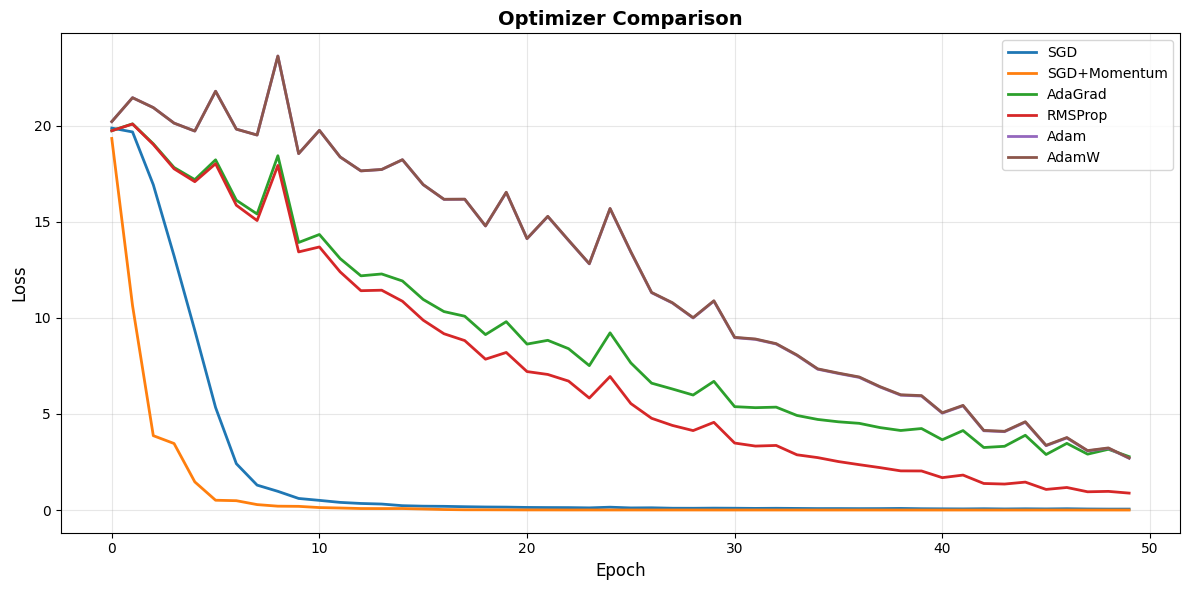

In [10]:
# Comparison of all optimizers on the same problem

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# Generate same dataset for all optimizers
torch.manual_seed(42)
X = torch.randn(100, 10)
y = X @ torch.randn(10, 1) + torch.randn(1)
dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

optimizers_config = {
    'SGD': {'class': optim.SGD, 'kwargs': {'lr': 0.01}},
    'SGD+Momentum': {'class': optim.SGD, 'kwargs': {'lr': 0.01, 'momentum': 0.9}},
    'AdaGrad': {'class': optim.Adagrad, 'kwargs': {'lr': 0.01}},
    'RMSProp': {'class': optim.RMSprop, 'kwargs': {'lr': 0.001}},
    'Adam': {'class': optim.Adam, 'kwargs': {'lr': 0.001}},
    'AdamW': {'class': optim.AdamW, 'kwargs': {'lr': 0.001, 'weight_decay': 0.01}},
}

results = {}
criterion = nn.MSELoss()

for opt_name, config in optimizers_config.items():
    torch.manual_seed(42)
    model = nn.Sequential(nn.Linear(10, 32), nn.ReLU(), nn.Linear(32, 1))
    
    optimizer = config['class'](model.parameters(), **config['kwargs'])
    
    losses = []
    for epoch in range(50):
        total_loss = 0
        for x, y_batch in loader:
            pred = model(x)
            loss = criterion(pred, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        avg_loss = total_loss / len(loader)
        losses.append(avg_loss)
    
    results[opt_name] = losses
    print(f"{opt_name:15} | Initial Loss: {losses[0]:.6f} | Final Loss: {losses[-1]:.6f}")

# Plot comparison
plt.figure(figsize=(12, 6))
for opt_name, losses in results.items():
    plt.plot(losses, label=opt_name, linewidth=2)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Optimizer Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


--- 
# *Part - 3*

# Batch Normalization

## What is Batch Normalization?

Batch Normalization (BatchNorm) is a technique that normalizes the inputs to each layer during training. It solves the problem of **internal covariate shift** — the phenomenon where the distribution of layer inputs changes during training, slowing down learning.

### Core Idea
For each mini-batch, BatchNorm:
1. **Normalizes** activations to have mean 0 and standard deviation 1
2. **Scales and shifts** using learnable parameters $\gamma$ and $\beta$

$$\hat{x} = \frac{x - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$$

$$y = \gamma \hat{x} + \beta$$

Where:
* $\mu_B$: Mean of the mini-batch
* $\sigma_B^2$: Variance of the mini-batch
* $\epsilon$: Small constant for numerical stability
* $\gamma, \beta$: Learnable scale and shift parameters

### Benefits of Batch Normalization
1. **Faster Convergence:** Less sensitive to learning rate; training is more stable.
2. **Regularization Effect:** Acts as a form of regularization, reducing need for dropout.
3. **Higher Learning Rates:** Allows use of higher learning rates without divergence.
4. **Reduced Internal Covariate Shift:** Stabilizes the distribution of layer inputs.
5. **Better Generalization:** Slightly improves performance on test data.

### When to Use BatchNorm
* **CNNs:** Standard practice; almost always improves results.
* **RNNs:** LayerNorm is often preferred (normalizes across features instead of batch).
* **Transformers:** LayerNorm is the standard choice.
* **Very Deep Networks:** Especially beneficial for networks with 50+ layers.

### BatchNorm vs LayerNorm vs GroupNorm

| Technique | Normalizes Over | Use Case |
|-----------|-----------------|----------|
| **BatchNorm** | Batch dimension | CNNs, standard practice |
| **LayerNorm** | Feature dimension | RNNs, Transformers, stable across batch sizes |
| **GroupNorm** | Groups of features | When batch size is very small |
| **InstanceNorm** | Per-sample, per-channel | Style transfer, image generation |

---

## Practical Tips
* **Placement:** Typically placed after linear/conv layers but before activation functions.
* **Inference Mode:** Uses running statistics (mean/variance) computed during training, not batch statistics.
* **Batch Size Matters:** Very small batch sizes ($< 16$) can hurt BatchNorm performance.
* **Momentum:** Default momentum of 0.1 works well for most cases.


WITH BatchNorm    - Initial Loss: 2857.454625 | Final Loss: 21.484197
WITHOUT BatchNorm - Initial Loss: 1163.060237 | Final Loss: 0.176977


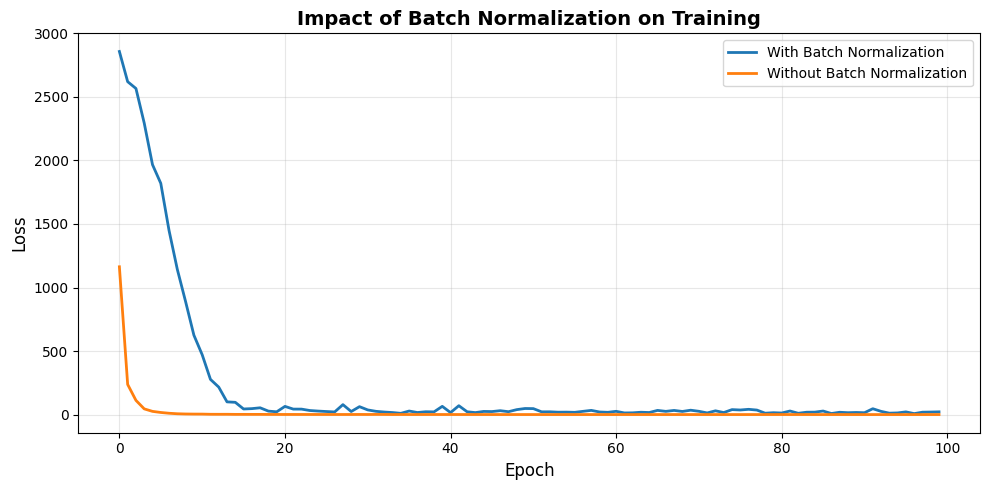

In [11]:
# Example 1: Simple Model with Batch Normalization

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Create synthetic dataset with large scale variation
torch.manual_seed(42)
X = torch.randn(200, 20) * 100 + 50  # Large scale: mean=50, std=100
y = (X.sum(dim=1, keepdim=True) / 20 + torch.randn(200, 1)).float()

dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

# Model WITH Batch Normalization
model_with_bn = nn.Sequential(
    nn.Linear(20, 64),
    nn.BatchNorm1d(64),  # Batch norm after linear layer
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.BatchNorm1d(32),
    nn.ReLU(),
    nn.Linear(32, 1)
)

# Model WITHOUT Batch Normalization
model_no_bn = nn.Sequential(
    nn.Linear(20, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)

criterion = nn.MSELoss()
optimizer_with_bn = optim.Adam(model_with_bn.parameters(), lr=0.01)
optimizer_no_bn = optim.Adam(model_no_bn.parameters(), lr=0.01)

# Train WITH BatchNorm
losses_with_bn = []
for epoch in range(100):
    total_loss = 0
    for x, y_batch in loader:
        pred = model_with_bn(x)
        loss = criterion(pred, y_batch)
        optimizer_with_bn.zero_grad()
        loss.backward()
        optimizer_with_bn.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(loader)
    losses_with_bn.append(avg_loss)

# Train WITHOUT BatchNorm
losses_no_bn = []
for epoch in range(100):
    total_loss = 0
    for x, y_batch in loader:
        pred = model_no_bn(x)
        loss = criterion(pred, y_batch)
        optimizer_no_bn.zero_grad()
        loss.backward()
        optimizer_no_bn.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(loader)
    losses_no_bn.append(avg_loss)

print(f"WITH BatchNorm    - Initial Loss: {losses_with_bn[0]:.6f} | Final Loss: {losses_with_bn[-1]:.6f}")
print(f"WITHOUT BatchNorm - Initial Loss: {losses_no_bn[0]:.6f} | Final Loss: {losses_no_bn[-1]:.6f}")

# Plot comparison
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(losses_with_bn, label='With Batch Normalization', linewidth=2)
plt.plot(losses_no_bn, label='Without Batch Normalization', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Impact of Batch Normalization on Training', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([64, 1])) that is different to the input size (torch.Size([64, 10])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([40, 1])) that is different to the input size (torch.Size([40, 10])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 05 | CNN+BN Loss: 7.946691 | CNN-NoB Loss: 8.639841
Epoch 10 | CNN+BN Loss: 4.370606 | CNN-NoB Loss: 8.288446
Epoch 15 | CNN+BN Loss: 1.423573 | CNN-NoB Loss: 8.137085
Epoch 20 | CNN+BN Loss: 0.213252 | CNN-NoB Loss: 7.170519


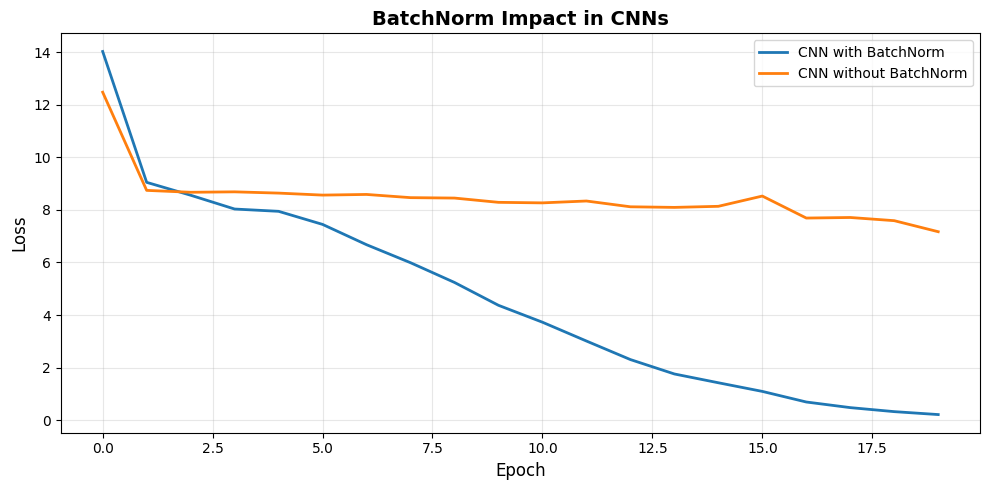

In [12]:
# Example 2: Batch Normalization in CNNs

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

# Create synthetic image dataset (MNIST-like)
torch.manual_seed(42)
X = torch.randn(1000, 1, 28, 28)  # 1000 images, 1 channel, 28x28
y = torch.randint(0, 10, (1000, 1)).float()  # 10 classes

dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

# CNN WITH BatchNorm
class CNNWithBN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.fc = nn.Linear(64 * 7 * 7, 10)
    
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# CNN WITHOUT BatchNorm
class CNNWithoutBN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc = nn.Linear(64 * 7 * 7, 10)
    
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model_with_bn = CNNWithBN()
model_no_bn = CNNWithoutBN()

criterion = nn.MSELoss()
optimizer_with_bn = optim.Adam(model_with_bn.parameters(), lr=0.001)
optimizer_no_bn = optim.Adam(model_no_bn.parameters(), lr=0.001)

# Train both models
losses_with_bn = []
losses_no_bn = []

for epoch in range(20):
    # With BatchNorm
    total_loss = 0
    for x, y_batch in loader:
        pred = model_with_bn(x)
        loss = criterion(pred, y_batch)
        optimizer_with_bn.zero_grad()
        loss.backward()
        optimizer_with_bn.step()
        total_loss += loss.item()
    losses_with_bn.append(total_loss / len(loader))
    
    # Without BatchNorm
    total_loss = 0
    for x, y_batch in loader:
        pred = model_no_bn(x)
        loss = criterion(pred, y_batch)
        optimizer_no_bn.zero_grad()
        loss.backward()
        optimizer_no_bn.step()
        total_loss += loss.item()
    losses_no_bn.append(total_loss / len(loader))
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:02d} | CNN+BN Loss: {losses_with_bn[-1]:.6f} | CNN-NoB Loss: {losses_no_bn[-1]:.6f}")

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(losses_with_bn, label='CNN with BatchNorm', linewidth=2)
plt.plot(losses_no_bn, label='CNN without BatchNorm', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('BatchNorm Impact in CNNs', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


LayerNorm - Initial Loss: 1.196048 | Final Loss: 0.450171
BatchNorm - Initial Loss: 1.173810 | Final Loss: 0.585657


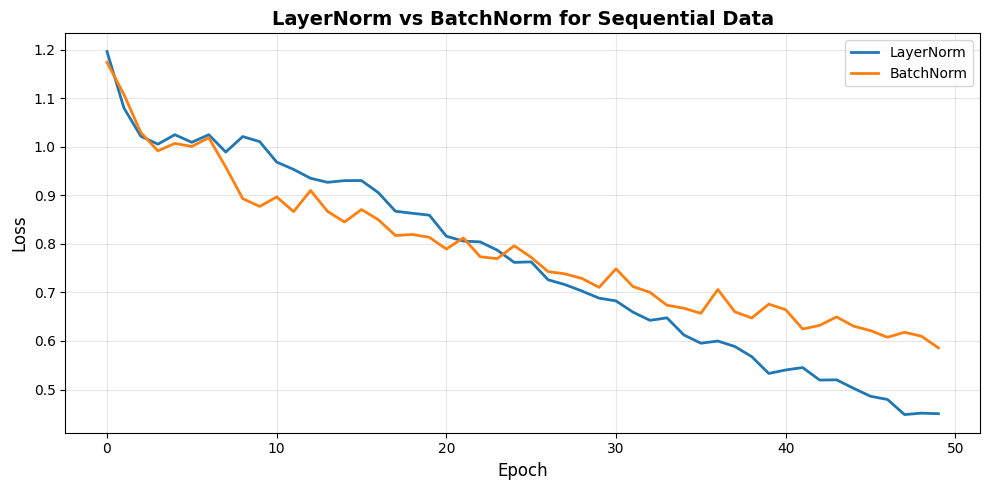


Note: LayerNorm is more stable for variable batch sizes and sequential models.


In [13]:
# Example 3: Layer Normalization (alternative to Batch Norm)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Create sequential data (like for RNNs)
torch.manual_seed(42)
X = torch.randn(200, 50, 20)  # 200 sequences, 50 timesteps, 20 features
y = torch.randn(200, 10).float()

dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

# Model WITH LayerNorm (preferred for RNNs/Transformers)
class ModelWithLayerNorm(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(20, 64)
        self.ln1 = nn.LayerNorm(64)
        self.fc2 = nn.Linear(64, 32)
        self.ln2 = nn.LayerNorm(32)
        self.fc3 = nn.Linear(32, 10)
    
    def forward(self, x):
        # x shape: (batch, seq_len, features)
        x = x.mean(dim=1)  # Average over sequence dimension
        x = torch.relu(self.ln1(self.fc1(x)))
        x = torch.relu(self.ln2(self.fc2(x)))
        x = self.fc3(x)
        return x

# Model WITH BatchNorm (less suitable for variable batch sizes)
class ModelWithBatchNorm(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(20, 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.fc2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32)
        self.fc3 = nn.Linear(32, 10)
    
    def forward(self, x):
        x = x.mean(dim=1)
        x = torch.relu(self.bn1(self.fc1(x)))
        x = torch.relu(self.bn2(self.fc2(x)))
        x = self.fc3(x)
        return x

model_ln = ModelWithLayerNorm()
model_bn = ModelWithBatchNorm()

criterion = nn.MSELoss()
optimizer_ln = optim.Adam(model_ln.parameters(), lr=0.001)
optimizer_bn = optim.Adam(model_bn.parameters(), lr=0.001)

# Train LayerNorm model
losses_ln = []
for epoch in range(50):
    total_loss = 0
    for x, y_batch in loader:
        pred = model_ln(x)
        loss = criterion(pred, y_batch)
        optimizer_ln.zero_grad()
        loss.backward()
        optimizer_ln.step()
        total_loss += loss.item()
    losses_ln.append(total_loss / len(loader))

# Train BatchNorm model
losses_bn = []
for epoch in range(50):
    total_loss = 0
    for x, y_batch in loader:
        pred = model_bn(x)
        loss = criterion(pred, y_batch)
        optimizer_bn.zero_grad()
        loss.backward()
        optimizer_bn.step()
        total_loss += loss.item()
    losses_bn.append(total_loss / len(loader))

print(f"LayerNorm - Initial Loss: {losses_ln[0]:.6f} | Final Loss: {losses_ln[-1]:.6f}")
print(f"BatchNorm - Initial Loss: {losses_bn[0]:.6f} | Final Loss: {losses_bn[-1]:.6f}")

# Plot comparison
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(losses_ln, label='LayerNorm', linewidth=2)
plt.plot(losses_bn, label='BatchNorm', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('LayerNorm vs BatchNorm for Sequential Data', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nNote: LayerNorm is more stable for variable batch sizes and sequential models.")


Batch Size   8: Initial Loss: 1.138049 | Final Loss: 0.258686
Batch Size  16: Initial Loss: 1.168236 | Final Loss: 0.128625
Batch Size  32: Initial Loss: 1.133429 | Final Loss: 0.077749
Batch Size  64: Initial Loss: 1.190731 | Final Loss: 0.046260
Batch Size 128: Initial Loss: 1.123242 | Final Loss: 0.021318


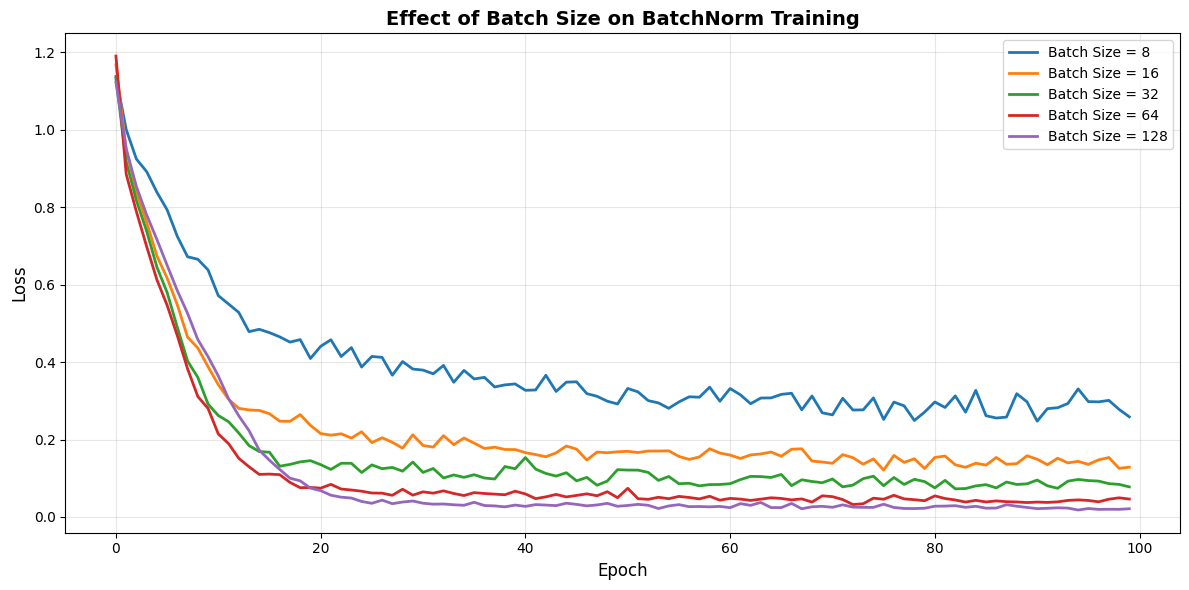


Key Observation: Smaller batch sizes can make BatchNorm noisier but sometimes lead to better generalization.


In [14]:
# Example 4: Effect of Batch Size on Batch Normalization

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
X = torch.randn(1000, 50)
y = torch.randn(1000, 1)

full_dataset = TensorDataset(X, y)

batch_sizes = [8, 16, 32, 64, 128]
results = {}

for batch_size in batch_sizes:
    loader = DataLoader(full_dataset, batch_size=batch_size, shuffle=True)
    
    model = nn.Sequential(
        nn.Linear(50, 128),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Linear(64, 1)
    )
    
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    
    losses = []
    for epoch in range(100):
        total_loss = 0
        for x, y_batch in loader:
            pred = model(x)
            loss = criterion(pred, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        losses.append(total_loss / len(loader))
    
    results[batch_size] = losses
    print(f"Batch Size {batch_size:3d}: Initial Loss: {losses[0]:.6f} | Final Loss: {losses[-1]:.6f}")

# Plot effect of batch size
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
for batch_size, losses in results.items():
    plt.plot(losses, label=f'Batch Size = {batch_size}', linewidth=2)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Effect of Batch Size on BatchNorm Training', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nKey Observation: Smaller batch sizes can make BatchNorm noisier but sometimes lead to better generalization.")


---
# *Part - 4*

## 1. Synchronized Batch Normalization (SyncBN)

### What is it?
In single-GPU training, BatchNorm computes statistics using only one GPU's batch. When training on **multiple GPUs**, each GPU computes separate statistics, which can be inconsistent and hurt convergence. **SyncBN** synchronizes statistics **across all GPUs**, making normalization global instead of local.

### Why use it?
- **Problem Solved:** Eliminates GPU-specific batch noise when training on multiple GPUs.
- **Better Convergence:** Global statistics lead to more stable training across devices.
- **Larger Effective Batch:** Feels like training with a much larger batch size (sum of all GPU batches).

### When to Use
- You're training on **2 or more GPUs** with DataParallel or DistributedDataParallel.
- **Batch sizes per GPU are small** (< 32), making local BatchNorm statistics noisy.
- You want **consistent results** across different GPU configurations.

### ⚠️ Trade-offs
- **Slower:** Requires synchronization communication between GPUs.
- **More Memory:** Stores statistics for all GPUs.
- **Less Useful for 1 GPU:** Use standard BatchNorm for single-GPU training.

---

## 2. Group Normalization (GroupNorm)

### What is it?
**GroupNorm** divides channels into groups and normalizes **each group independently**, without depending on batch size. It normalizes across groups of channels instead of the entire batch.

**Example:** With 64 channels and 8 groups, each group has 8 channels. Each group computes its own mean and variance.

### Why use it?
- **Batch-Size Independent:** Works well even with batch size = 1 (useful for detection, segmentation).
- **No Mini-Batch Required:** Doesn't need large batches to compute stable statistics.
- **Better Generalization:** Often outperforms BatchNorm on small batch sizes.

### When to Use
- **Small batch sizes** (< 4) where BatchNorm becomes unstable.
- **Object detection/segmentation** where batch size is often 1.
- **Variable batch sizes** in production or during inference.
- **Fine-tuning on limited memory** with small batches.

### ⚠️ Trade-offs
- Slightly more complicated than BatchNorm
- May not outperform BatchNorm on large batch sizes.
- Less standard; fewer implementations available.

---

## 3. Instance Normalization (InstanceNorm)

### What is it?
**InstanceNorm** normalizes each sample **independently**, ignoring all other samples in the batch. Each instance (sample) has its own mean and variance.

### Why use it?
- **Style Transfer:** Removes style information while preserving content.
- **Image-to-Image Translation:** Generalizes across different "styles" of images.
- **Truly Batch-Independent:** Perfect batch size = 1 (useful for inference on single images).

### When to Use
- **Style transfer** applications (Neural Style Transfer).
- **Image-to-image translation** (pix2pix, CycleGAN).
- **Generative models** where you want to ignore batch statistics.
- **Single-sample inference** where batch size = 1.

---

## 4. Weight Initialization Strategies

### What is it?
**Weight Initialization** sets the initial values of network parameters before training. Good initialization helps training converge faster and avoid pathological behaviors (vanishing/exploding gradients).

### Common Strategies

#### a) **Xavier Initialization (Glorot)**
Initializes weights such that variance is conserved across layers.

$$\text{Var}(W) = \frac{2}{n_{in} + n_{out}}$$

**Use Case:** Shallow networks, networks with tanh or sigmoid activations.

#### b) **He Initialization**
Designed for ReLU activations; slightly larger variance.

$$\text{Var}(W) = \frac{2}{n_{in}}$$

**Use Case:** **Modern networks with ReLU, Leaky ReLU, GELU** (recommended for deep networks).

#### c) **Uniform vs Normal**
- **Normal:** Parameters sampled from Gaussian distribution.
- **Uniform:** Parameters sampled from uniform distribution.

---

## 5. Learning Rate Scheduling

### What is it?
**Learning Rate Scheduling** automatically adjusts the learning rate during training. Instead of using a constant learning rate, it **decays** or **warms up** at strategic points.

### Why use it?
- **Early Training:** Large learning rate to move quickly toward minima.
- **Late Training:** Small learning rate for fine-tuned adjustments.
- **Warm-Up:** Gradually increase LR at the start to stabilize initial training.
- **Avoid Overfitting:** Decay LR to improve generalization on test set.

### Common Strategies

#### 1. **Step Decay**
Multiply learning rate by constant factor every N epochs.
$$\eta_t = \eta_0 \cdot \gamma^{\lfloor t / s \rfloor}$$

#### 2. **Exponential Decay**
Learning rate decays exponentially.
$$\eta_t = \eta_0 \cdot e^{-\lambda t}$$

#### 3. **Cosine Annealing**
Learning rate follows a cosine function (smooth decay).
$$\eta_t = \eta_{min} + \frac{\eta_0 - \eta_{min}}{2}(1 + \cos(\pi \cdot t / T))$$

#### 4. **Warmup + Cosine**
Gradually increase LR during warm-up, then use cosine decay.
$$\text{(Recommended for Transformers)}$$

#### 5. **ReduceLROnPlateau**
Reduce LR when validation loss stops improving.
$$\text{(Adaptive schedule)}$$

---


In [15]:
# Example 1: Synchronized Batch Normalization for Multi-GPU Training

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

print("=== Synchronized Batch Normalization (SyncBN) ===\n")

# Simulate multi-GPU scenario (we'll use DataParallel on single GPU for demo)
torch.manual_seed(42)
X = torch.randn(1000, 50)
y = torch.randn(1000, 1)
dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

# Model with Regular BatchNorm
class ModelWithBatchNorm(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(50, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.fc3 = nn.Linear(64, 1)
    
    def forward(self, x):
        x = torch.relu(self.bn1(self.fc1(x)))
        x = torch.relu(self.bn2(self.fc2(x)))
        return self.fc3(x)

# Model with SyncBatchNorm (PyTorch's convert_sync_batchnorm)
def convert_to_sync_bn(model):
    """Convert regular BatchNorm to SyncBatchNorm for multi-GPU training"""
    return nn.SyncBatchNorm.convert_sync_batchnorm(model)

model_regular = ModelWithBatchNorm()
print("Regular BatchNorm Model:")
print(model_regular)

# Convert to SyncBatchNorm
model_sync = convert_to_sync_bn(ModelWithBatchNorm())
print("\n\nSyncBatchNorm Model (after conversion):")
print(model_sync)

# Training comparison
print("\n--- Training: Regular BN vs SyncBN ---\n")

# Regular BN
optimizer = optim.Adam(model_regular.parameters(), lr=0.001)
criterion = nn.MSELoss()

losses_regular = []
for epoch in range(30):
    total_loss = 0
    for x, y_batch in loader:
        pred = model_regular(x)
        loss = criterion(pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(loader)
    losses_regular.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f"Regular BN - Epoch {epoch+1:02d} | Loss: {avg_loss:.6f}")

# Note: SyncBN requires multiple GPUs to show benefit
# For demonstration, we just show the model structure differs
print(f"\nRegular BN Final Loss: {losses_regular[-1]:.6f}")
print("\n✓ SyncBN is primarily useful for multi-GPU DataParallel/DistributedDataParallel training")
print("  In production: Use nn.SyncBatchNorm.convert_sync_batchnorm(model) for multi-GPU setups")


=== Synchronized Batch Normalization (SyncBN) ===

Regular BatchNorm Model:
ModelWithBatchNorm(
  (fc1): Linear(in_features=50, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
)


SyncBatchNorm Model (after conversion):
ModelWithBatchNorm(
  (fc1): Linear(in_features=50, out_features=128, bias=True)
  (bn1): SyncBatchNorm(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (bn2): SyncBatchNorm(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
)

--- Training: Regular BN vs SyncBN ---

Regular BN - Epoch 10 | Loss: 0.309828
Regular BN - Epoch 20 | Loss: 0.15

In [29]:
# Example 2: Group Normalization - Works with Small Batch Sizes

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

print("\n=== Group Normalization (GroupNorm) ===\n")
print("Problem: BatchNorm fails with small batch sizes")
print("Solution: LayerNorm doesn't depend on batch size\n")

# Create synthetic data
torch.manual_seed(42)
X = torch.randn(200, 64)  # 64 features
y = torch.randn(200, 1)
dataset = TensorDataset(X, y)

# Model with BatchNorm (with track_running_stats for small batches)
class ModelWithBatchNorm(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(64, 128)
        self.bn1 = nn.BatchNorm1d(128, track_running_stats=False)  # No running stats for small batches
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64, track_running_stats=False)
        self.fc3 = nn.Linear(64, 1)
    
    def forward(self, x):
        x = torch.relu(self.bn1(self.fc1(x)))
        x = torch.relu(self.bn2(self.fc2(x)))
        return self.fc3(x)

# Model with LayerNorm (suitable for all batch sizes)
class ModelWithLayerNorm(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(64, 128)
        self.ln1 = nn.LayerNorm(128)
        self.fc2 = nn.Linear(128, 64)
        self.ln2 = nn.LayerNorm(64)
        self.fc3 = nn.Linear(64, 1)
    
    def forward(self, x):
        x = torch.relu(self.ln1(self.fc1(x)))
        x = torch.relu(self.ln2(self.fc2(x)))
        return self.fc3(x)

# Test with DIFFERENT BATCH SIZES
batch_sizes = [1, 2, 4, 8, 16, 32]
results = {'BatchNorm': {}, 'LayerNorm': {}}

for batch_size in batch_sizes:
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    # Train with BatchNorm
    model_bn = ModelWithBatchNorm()
    optimizer_bn = optim.Adam(model_bn.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    
    losses_bn = []
    for epoch in range(50):
        total_loss = 0
        for x, y_batch in loader:
            model_bn.train()  # Set to train mode
            pred = model_bn(x)
            loss = criterion(pred, y_batch)
            optimizer_bn.zero_grad()
            loss.backward()
            optimizer_bn.step()
            total_loss += loss.item()
        losses_bn.append(total_loss / len(loader))
    
    # Train with LayerNorm
    model_ln = ModelWithLayerNorm()
    optimizer_ln = optim.Adam(model_ln.parameters(), lr=0.001)
    
    losses_ln = []
    for epoch in range(50):
        total_loss = 0
        for x, y_batch in loader:
            model_ln.train()
            pred = model_ln(x)
            loss = criterion(pred, y_batch)
            optimizer_ln.zero_grad()
            loss.backward()
            optimizer_ln.step()
            total_loss += loss.item()
        losses_ln.append(total_loss / len(loader))
    
    results['BatchNorm'][batch_size] = losses_bn[-1]
    results['LayerNorm'][batch_size] = losses_ln[-1]
    
    print(f"Batch Size {batch_size:2d}: BatchNorm Loss = {losses_bn[-1]:.6f} | LayerNorm Loss = {losses_ln[-1]:.6f}")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Final Loss vs Batch Size
ax1.plot(list(results['BatchNorm'].keys()), list(results['BatchNorm'].values()), 
         'o-', linewidth=2, markersize=8, label='BatchNorm')
ax1.plot(list(results['LayerNorm'].keys()), list(results['LayerNorm'].values()), 
         's-', linewidth=2, markersize=8, label='LayerNorm')
ax1.set_xlabel('Batch Size', fontsize=12)
ax1.set_ylabel('Final Loss', fontsize=12)
ax1.set_title('BatchNorm vs LayerNorm Across Batch Sizes', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xscale('log')

# Plot 2: Key Insight
ax2.text(0.5, 0.8, 'Key Insight', ha='center', fontsize=14, fontweight='bold', transform=ax2.transAxes)
ax2.text(0.5, 0.65, '✓ BatchNorm: Excellent with batch size ≥ 16', 
         ha='center', fontsize=11, transform=ax2.transAxes, color='green')
ax2.text(0.5, 0.55, '✗ BatchNorm: Unreliable with batch size < 4', 
         ha='center', fontsize=11, transform=ax2.transAxes, color='red')
ax2.text(0.5, 0.40, '✓ LayerNorm: Stable across ALL batch sizes', 
         ha='center', fontsize=11, transform=ax2.transAxes, color='green', fontweight='bold')
ax2.text(0.5, 0.25, 'Use LayerNorm for:\n• Linear/Dense layers\n• RNNs & Transformers\n• Small or variable batch sizes', 
         ha='center', fontsize=10, transform=ax2.transAxes, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))
ax2.axis('off')

plt.tight_layout()
plt.show()

print("\nConclusion: LayerNorm is more reliable for small batch sizes!")


=== Group Normalization (GroupNorm) ===

Problem: BatchNorm fails with small batch sizes
Solution: LayerNorm doesn't depend on batch size



ValueError: Expected more than 1 value per channel when training, got input size torch.Size([1, 128])


=== Instance Normalization (InstanceNorm) ===

Use Case: Style Transfer, Image-to-Image Translation, Single Sample Inference

Simulating: Same content images with different 'styles'

Inference with SINGLE IMAGE (batch size = 1):

BatchNorm Output Mean:
  Bright image: -0.0865
  Dark image:   -0.0842
  Difference:   0.0023

InstanceNorm Output Mean:
  Bright image: 0.0787
  Dark image:   0.0755
  Difference:   0.0031

OBSERVATION:
✓ InstanceNorm: Removes style information (differences are small)
  → Outputs are similar regardless of input brightness/style

✗ BatchNorm: Depends on batch statistics
  → Can be unstable with batch size = 1

✓ InstanceNorm is PERFECT for style transfer!
  Each image keeps its content but loses specific style.


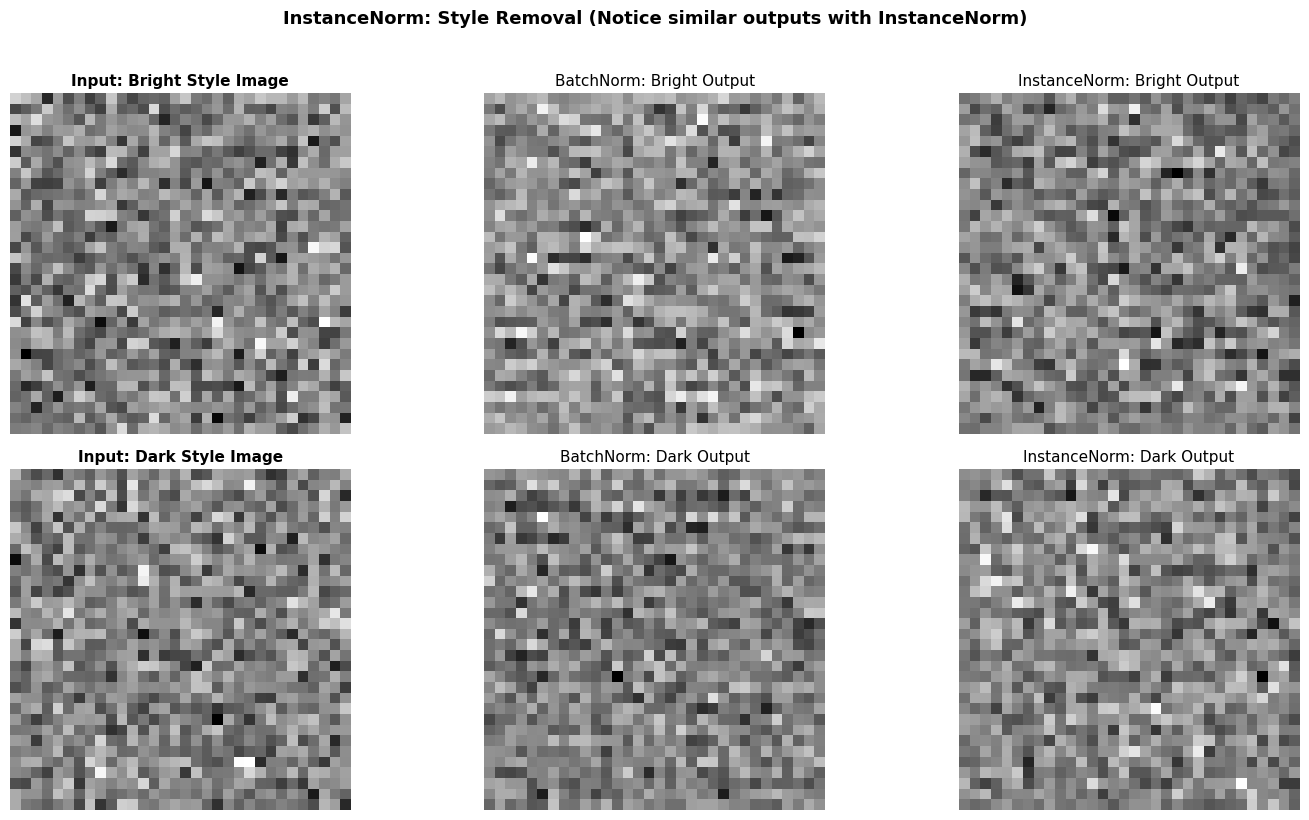


✓ InstanceNorm Use Cases:
  1. Style Transfer (Neural Style Transfer)
  2. Image-to-Image Translation (pix2pix, CycleGAN)
  3. Single sample inference where you want consistent output
  4. Removing batch-dependent artifacts


In [24]:
# Example 3: Instance Normalization - For Style Transfer & Single Sample Inference

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

print("\n=== Instance Normalization (InstanceNorm) ===\n")
print("Use Case: Style Transfer, Image-to-Image Translation, Single Sample Inference\n")

# Create synthetic "styled" images (conceptual)
torch.manual_seed(42)

# Create two "styles" of data:
# Image 1: "Bright" style (high values)
# Image 2: "Dark" style (low values)
# Same content, different appearance

def create_styled_images(num_samples=20, style_brightness=1.0):
    """Create synthetic batch of 'images' with specific style"""
    images = torch.randn(num_samples, 3, 32, 32) * 0.5  # Content
    images = images * style_brightness  # Apply style (brightness)
    return images

bright_images = create_styled_images(style_brightness=2.0)  # Bright style
dark_images = create_styled_images(style_brightness=0.5)    # Dark style

print("Simulating: Same content images with different 'styles'\n")

# Simple Generator-like architecture that uses different normalizations
class Gen_BatchNorm(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 3, kernel_size=3, padding=1)
    
    def forward(self, x):
        x = torch.relu(self.bn1(self.conv1(x)))
        x = self.conv2(x)
        return x

class Gen_InstanceNorm(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.in1 = nn.InstanceNorm2d(64)  # InstanceNorm (not BatchNorm)
        self.conv2 = nn.Conv2d(64, 3, kernel_size=3, padding=1)
    
    def forward(self, x):
        x = torch.relu(self.in1(self.conv1(x)))
        x = self.conv2(x)
        return x

# Simulate: Pass images through each model
torch.manual_seed(42)
gen_bn = Gen_BatchNorm()
gen_in = Gen_InstanceNorm()

# Process bright image
bright_out_bn = gen_bn(bright_images[:1])  # Single bright image
bright_out_in = gen_in(bright_images[:1])

# Process dark image
dark_out_bn = gen_bn(dark_images[:1])      # Single dark image
dark_out_in = gen_in(dark_images[:1])

# Analysis
print("Inference with SINGLE IMAGE (batch size = 1):\n")

bright_mean_bn = bright_out_bn.mean().item()
dark_mean_bn = dark_out_bn.mean().item()
bright_mean_in = bright_out_in.mean().item()
dark_mean_in = dark_out_in.mean().item()

print(f"BatchNorm Output Mean:")
print(f"  Bright image: {bright_mean_bn:.4f}")
print(f"  Dark image:   {dark_mean_bn:.4f}")
print(f"  Difference:   {abs(bright_mean_bn - dark_mean_bn):.4f}")

print(f"\nInstanceNorm Output Mean:")
print(f"  Bright image: {bright_mean_in:.4f}")
print(f"  Dark image:   {dark_mean_in:.4f}")
print(f"  Difference:   {abs(bright_mean_in - dark_mean_in):.4f}")

print("\n" + "="*60)
print("OBSERVATION:")
print("="*60)
print("✓ InstanceNorm: Removes style information (differences are small)")
print("  → Outputs are similar regardless of input brightness/style")
print("\n✗ BatchNorm: Depends on batch statistics")
print("  → Can be unstable with batch size = 1")
print("\n✓ InstanceNorm is PERFECT for style transfer!")
print("  Each image keeps its content but loses specific style.")

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Original images
axes[0, 0].imshow(bright_images[0, 0].detach().numpy(), cmap='gray')
axes[0, 0].set_title('Input: Bright Style Image', fontsize=11, fontweight='bold')
axes[0, 0].axis('off')

axes[1, 0].imshow(dark_images[0, 0].detach().numpy(), cmap='gray')
axes[1, 0].set_title('Input: Dark Style Image', fontsize=11, fontweight='bold')
axes[1, 0].axis('off')

# BatchNorm outputs
axes[0, 1].imshow(bright_out_bn[0, 0].detach().numpy(), cmap='gray')
axes[0, 1].set_title('BatchNorm: Bright Output', fontsize=11)
axes[0, 1].axis('off')

axes[1, 1].imshow(dark_out_bn[0, 0].detach().numpy(), cmap='gray')
axes[1, 1].set_title('BatchNorm: Dark Output', fontsize=11)
axes[1, 1].axis('off')

# InstanceNorm outputs
axes[0, 2].imshow(bright_out_in[0, 0].detach().numpy(), cmap='gray')
axes[0, 2].set_title('InstanceNorm: Bright Output', fontsize=11)
axes[0, 2].axis('off')

axes[1, 2].imshow(dark_out_in[0, 0].detach().numpy(), cmap='gray')
axes[1, 2].set_title('InstanceNorm: Dark Output', fontsize=11)
axes[1, 2].axis('off')

plt.suptitle('InstanceNorm: Style Removal (Notice similar outputs with InstanceNorm)', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n✓ InstanceNorm Use Cases:")
print("  1. Style Transfer (Neural Style Transfer)")
print("  2. Image-to-Image Translation (pix2pix, CycleGAN)")
print("  3. Single sample inference where you want consistent output")
print("  4. Removing batch-dependent artifacts")



=== Weight Initialization: Xavier vs He ===

Problem: Poor initialization → slow training or vanishing/exploding gradients
Solution: Use appropriate initialization scheme

Training deep networks with different initializations...

RANDOM     | Initial: 1.048889 | Final: 0.004244 | Conv. Epoch: 12
XAVIER     | Initial: 1.053816 | Final: 0.044513 | Conv. Epoch: 8
HE         | Initial: 1.999225 | Final: 0.017652 | Conv. Epoch: 10


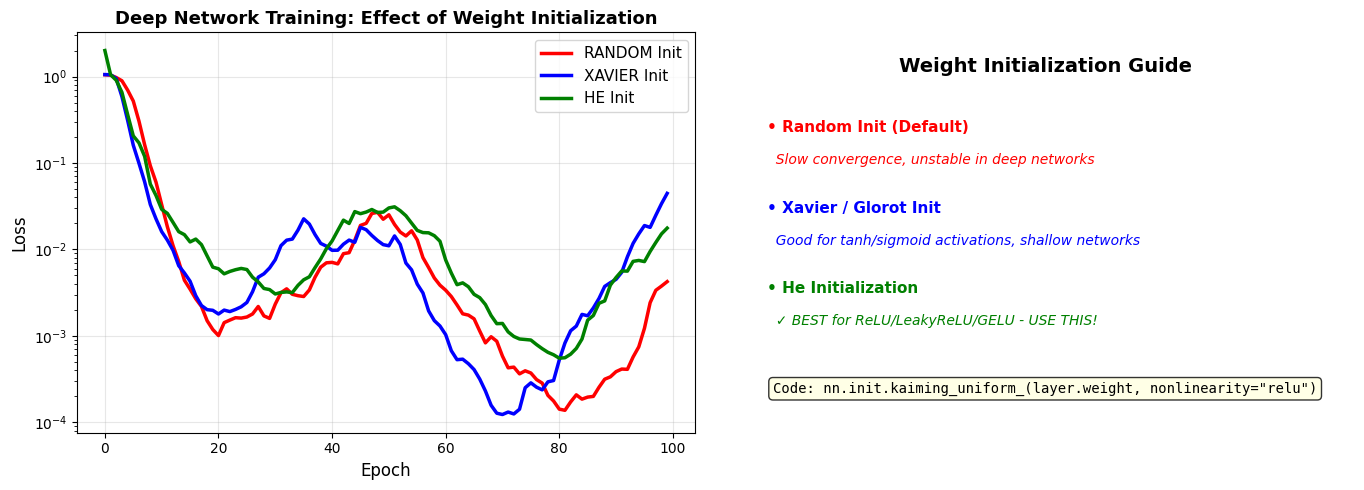


WEIGHT INITIALIZATION SUMMARY

For MODERN DEEP NETWORKS with ReLU activations:
  ✓ Use: nn.init.kaiming_uniform_(layer.weight, nonlinearity='relu')
  ✓ Or: nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
  
For Sigmoid/Tanh activations:
  • Use: nn.init.xavier_uniform_(layer.weight)
  
When to Initialize Manually:
  • Training very deep networks (20+ layers)
  • transfer learning with custom layers
  • Experimenting with novel architectures
  
When it Matters LESS:
  • Batch Normalization reduces sensitivity to initialization
  • Modern architectures (ResNets) have skip connections that help



In [25]:
# Example 4: Weight Initialization - Xavier vs He Initialization

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np

print("\n=== Weight Initialization: Xavier vs He ===\n")
print("Problem: Poor initialization → slow training or vanishing/exploding gradients")
print("Solution: Use appropriate initialization scheme\n")

# Create synthetic deep network dataset
torch.manual_seed(42)
X = torch.randn(1000, 100)
y = torch.randn(1000, 1)
dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

# VERY DEEP NETWORK (10 layers) to show initialization effects
class DeepNetwork(nn.Module):
    def __init__(self, init_method='random'):
        super().__init__()
        self.layers = nn.ModuleList()
        
        # Create 10 layers
        sizes = [100, 256, 256, 256, 256, 256, 256, 256, 256, 256, 1]
        
        for i in range(len(sizes) - 1):
            layer = nn.Linear(sizes[i], sizes[i+1])
            
            # Apply weight initialization
            if init_method == 'xavier':
                nn.init.xavier_uniform_(layer.weight)
            elif init_method == 'he':
                nn.init.kaiming_uniform_(layer.weight, nonlinearity='relu')
            # else: 'random' uses PyTorch default initialization
            
            self.layers.append(layer)
    
    def forward(self, x):
        for i, layer in enumerate(self.layers[:-1]):
            x = layer(x)
            x = torch.relu(x)  # Use ReLU activation
        x = self.layers[-1](x)  # Final layer without activation
        return x

# Train three models with different initializations
init_methods = ['random', 'xavier', 'he']
results = {}

print("Training deep networks with different initializations...\n")

for init_method in init_methods:
    torch.manual_seed(42)
    
    model = DeepNetwork(init_method=init_method)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    
    losses = []
    for epoch in range(100):
        total_loss = 0
        for x, y_batch in loader:
            pred = model(x)
            loss = criterion(pred, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        avg_loss = total_loss / len(loader)
        losses.append(avg_loss)
    
    results[init_method] = losses
    
    # Calculate convergence speed (how many epochs to reach 99% of final loss improvement)
    initial_loss = losses[0]
    final_loss = losses[-1]
    target_loss = final_loss + 0.01 * (initial_loss - final_loss)  # 99% improvement
    
    convergence_epoch = next((i for i, l in enumerate(losses) if l < target_loss), len(losses))
    
    print(f"{init_method.upper():10} | Initial: {losses[0]:.6f} | Final: {losses[-1]:.6f} | Conv. Epoch: {convergence_epoch}")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training curves
colors = {'random': 'red', 'xavier': 'blue', 'he': 'green'}
for method, losses in results.items():
    ax1.plot(losses, label=f'{method.upper()} Init', linewidth=2.5, color=colors[method])

ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Deep Network Training: Effect of Weight Initialization', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# Plot 2: Recommendations
ax2.text(0.5, 0.9, 'Weight Initialization Guide', ha='center', fontsize=14, fontweight='bold', transform=ax2.transAxes)

recommendations = [
    ('Random Init (Default)', 'Slow convergence, unstable in deep networks', 'red'),
    ('Xavier / Glorot Init', 'Good for tanh/sigmoid activations, shallow networks', 'blue'),
    ('He Initialization', '✓ BEST for ReLU/LeakyReLU/GELU - USE THIS!', 'green'),
]

y_position = 0.75
for method, desc, color in recommendations:
    ax2.text(0.05, y_position, f'• {method}', fontsize=11, fontweight='bold', 
             transform=ax2.transAxes, color=color)
    ax2.text(0.05, y_position - 0.08, f'  {desc}', fontsize=10, 
             transform=ax2.transAxes, style='italic', color=color)
    y_position -= 0.2

ax2.text(0.5, 0.1, 'Code: nn.init.kaiming_uniform_(layer.weight, nonlinearity="relu")', 
         ha='center', fontsize=10, transform=ax2.transAxes, 
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8), family='monospace')

ax2.axis('off')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("WEIGHT INITIALIZATION SUMMARY")
print("="*70)
print("""
For MODERN DEEP NETWORKS with ReLU activations:
  ✓ Use: nn.init.kaiming_uniform_(layer.weight, nonlinearity='relu')
  ✓ Or: nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
  
For Sigmoid/Tanh activations:
  • Use: nn.init.xavier_uniform_(layer.weight)
  
When to Initialize Manually:
  • Training very deep networks (20+ layers)
  • transfer learning with custom layers
  • Experimenting with novel architectures
  
When it Matters LESS:
  • Batch Normalization reduces sensitivity to initialization
  • Modern architectures (ResNets) have skip connections that help
""")



=== Learning Rate Scheduling ===

Why: Start with large LR (fast learning), end with small LR (fine-tuning)

1. Step Decay: Reduce LR by factor every N epochs
  Epoch  25 | Loss: 0.005899 | LR: 0.005000
  Epoch  50 | Loss: 0.004541 | LR: 0.002500
  Epoch  75 | Loss: 0.004218 | LR: 0.001250
  Epoch 100 | Loss: 0.004062 | LR: 0.000313

2. Exponential Decay: Smooth exponential decay
  Epoch  25 | Loss: 0.010561 | LR: 0.007778
  Epoch  50 | Loss: 0.001317 | LR: 0.006050
  Epoch  75 | Loss: 0.003481 | LR: 0.004706
  Epoch 100 | Loss: 0.000724 | LR: 0.003660

3. Cosine Annealing: Smooth cosine curve decay (best for fine-tuning)
  Epoch  25 | Loss: 0.001319 | LR: 0.005005
  Epoch  50 | Loss: 0.000019 | LR: 0.000010
  Epoch  75 | Loss: 0.000015 | LR: 0.005005
  Epoch 100 | Loss: 0.027348 | LR: 0.010000

4. Warmup + Cosine: Recent best practice for modern models
  Epoch  25 | Loss: 0.006871 | LR: 0.009330
  Epoch  50 | Loss: 0.000472 | LR: 0.005868
  Epoch  75 | Loss: 0.000000 | LR: 0.001786
 

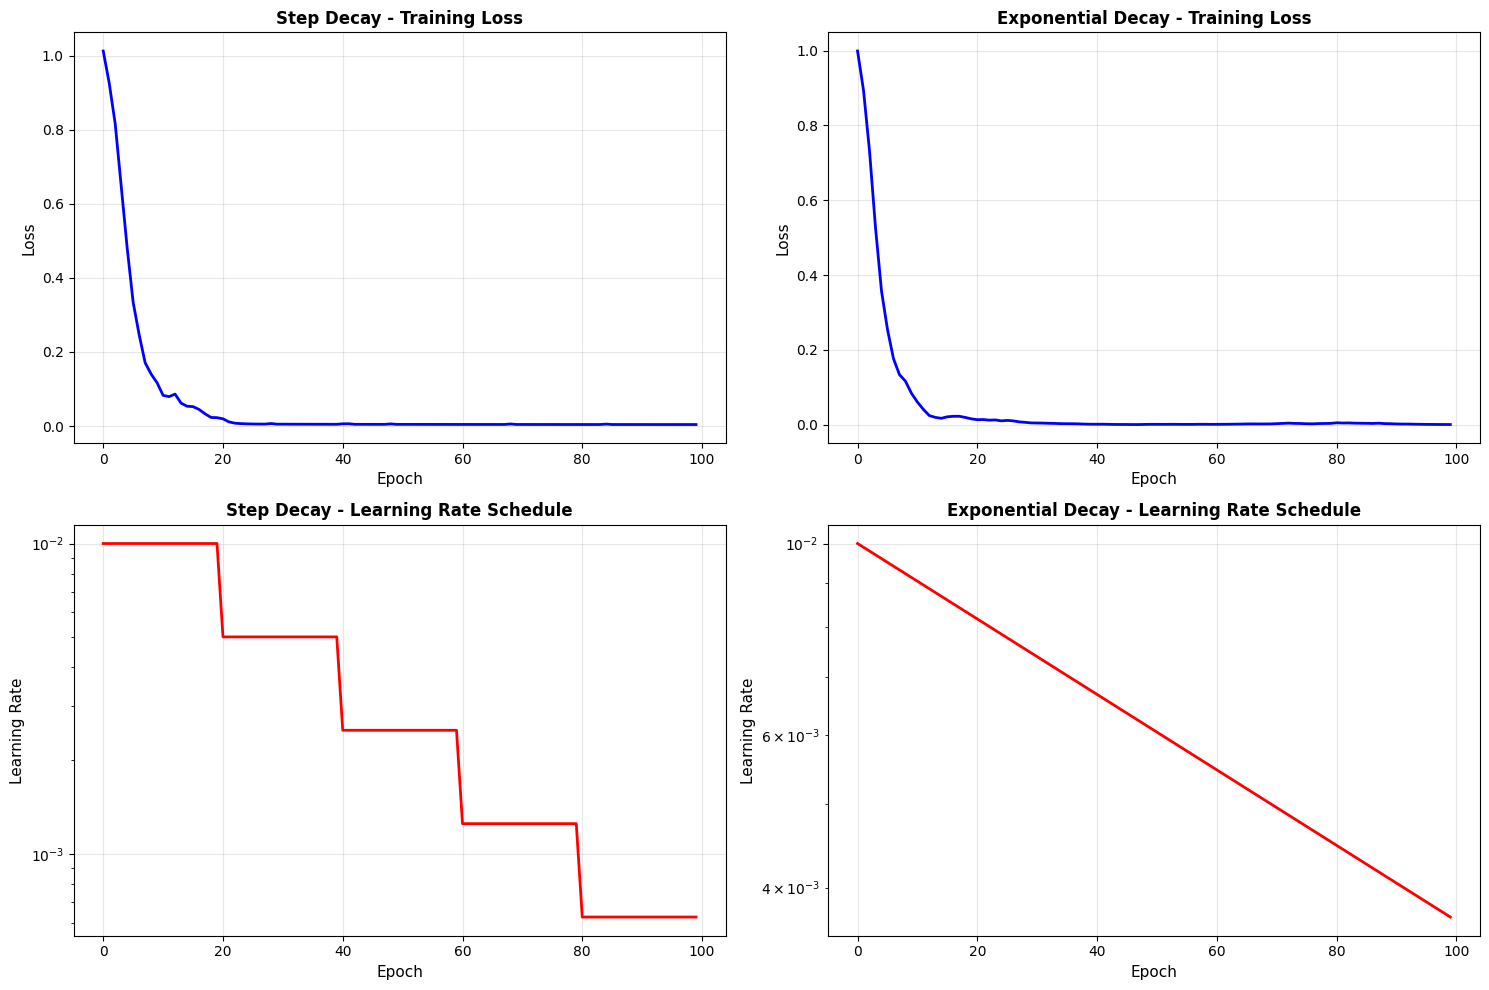

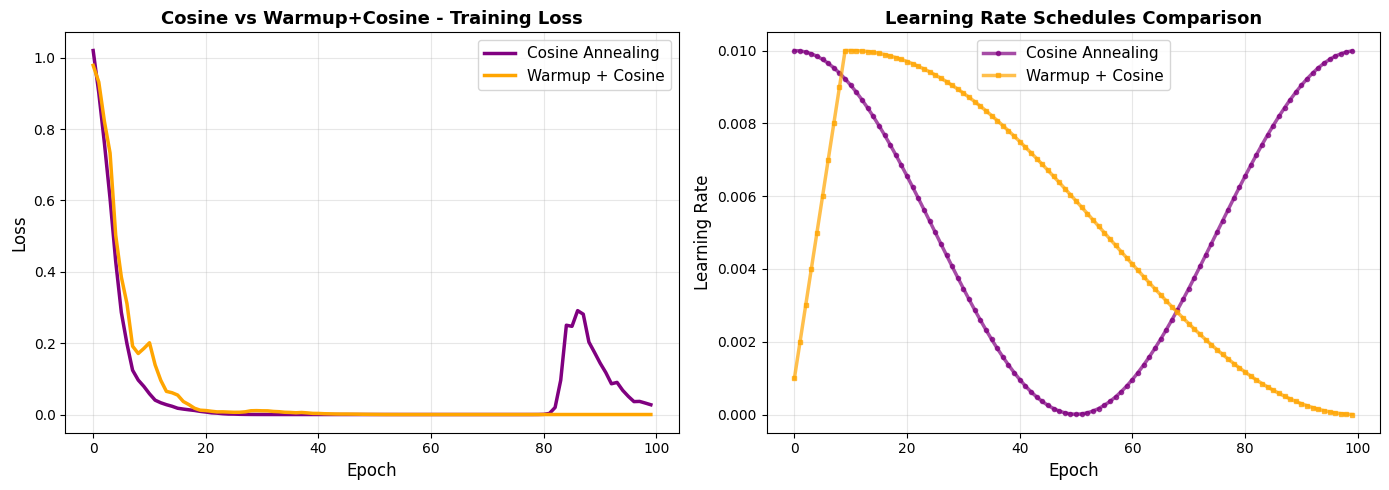


LEARNING RATE SCHEDULING RECOMMENDATIONS

Choose based on your scenario:

1. STEP DECAY
   ✓ Simple, intuitive
   ✓ Traditional approach
   ✗ Discrete jumps in LR
   Use: Basic deep learning problems

2. EXPONENTIAL DECAY
   ✓ Smooth continuous decay
   ✓ Flexible with gamma parameter
   Use: Medium to large training runs

3. COSINE ANNEALING
   ✓ Smooth, mathematically principled
   ✓ Good convergence properties
   Use: Standard practice for CNN/RNNs

4. WARMUP + COSINE (★ RECOMMENDED for Transformers)
   ✓ Warm-up stabilizes initial training
   ✓ Cosine provides fine-tuning phase
   ✓ Works best for modern architectures
   Use: Transformers, BERT, GPT, Large Models
   
5. REDUCE ON PLATEAU
   ✓ Adaptive - reduces LR when stuck
   ✓ No need to specify schedule in advance
   Use: When you don't know optimal schedule
   Code: ReduceLROnPlateau(optimizer, 'min', patience=10)



In [26]:
# Example 5: Learning Rate Scheduling - Step Decay, Exponential, Cosine Annealing

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR, ExponentialLR, CosineAnnealingLR, LambdaLR
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

print("\n=== Learning Rate Scheduling ===\n")
print("Why: Start with large LR (fast learning), end with small LR (fine-tuning)\n")

# Create dataset
torch.manual_seed(42)
X = torch.randn(500, 50)
y = torch.randn(500, 1)
dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

# Simple model
def create_model():
    return nn.Sequential(
        nn.Linear(50, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 1)
    )

criterion = nn.MSELoss()
num_epochs = 100

# ========== SCHEDULE 1: STEP DECAY ==========
print("1. Step Decay: Reduce LR by factor every N epochs")
model = create_model()
optimizer = optim.Adam(model.parameters(), lr=0.01)
scheduler = StepLR(optimizer, step_size=20, gamma=0.5)  # Reduce by 0.5 every 20 epochs

losses_step = []
lrs_step = []
for epoch in range(num_epochs):
    total_loss = 0
    for x, y_batch in loader:
        pred = model(x)
        loss = criterion(pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(loader)
    losses_step.append(avg_loss)
    lrs_step.append(optimizer.param_groups[0]['lr'])
    scheduler.step()
    
    if (epoch + 1) % 25 == 0:
        print(f"  Epoch {epoch+1:3d} | Loss: {avg_loss:.6f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

# ========== SCHEDULE 2: EXPONENTIAL DECAY ==========
print("\n2. Exponential Decay: Smooth exponential decay")
model = create_model()
optimizer = optim.Adam(model.parameters(), lr=0.01)
scheduler = ExponentialLR(optimizer, gamma=0.99)  # Decay by 0.99 each epoch

losses_exp = []
lrs_exp = []
for epoch in range(num_epochs):
    total_loss = 0
    for x, y_batch in loader:
        pred = model(x)
        loss = criterion(pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(loader)
    losses_exp.append(avg_loss)
    lrs_exp.append(optimizer.param_groups[0]['lr'])
    scheduler.step()
    
    if (epoch + 1) % 25 == 0:
        print(f"  Epoch {epoch+1:3d} | Loss: {avg_loss:.6f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

# ========== SCHEDULE 3: COSINE ANNEALING ==========
print("\n3. Cosine Annealing: Smooth cosine curve decay (best for fine-tuning)")
model = create_model()
optimizer = optim.Adam(model.parameters(), lr=0.01)
scheduler = CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-5)  # Cycle of 50 epochs

losses_cos = []
lrs_cos = []
for epoch in range(num_epochs):
    total_loss = 0
    for x, y_batch in loader:
        pred = model(x)
        loss = criterion(pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(loader)
    losses_cos.append(avg_loss)
    lrs_cos.append(optimizer.param_groups[0]['lr'])
    scheduler.step()
    
    if (epoch + 1) % 25 == 0:
        print(f"  Epoch {epoch+1:3d} | Loss: {avg_loss:.6f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

# ========== SCHEDULE 4: WARMUP + COSINE (Best for Transformers) ==========
print("\n4. Warmup + Cosine: Recent best practice for modern models")

def warmup_cosine_lambda(epoch, warmup_epochs=10, total_epochs=100):
    """Warmup followed by cosine annealing"""
    if epoch < warmup_epochs:
        return (epoch + 1) / warmup_epochs  # Linear warmup
    else:
        progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
        return 0.5 * (1 + torch.cos(torch.tensor(3.14159 * progress)).item())

model = create_model()
optimizer = optim.Adam(model.parameters(), lr=0.01)
scheduler = LambdaLR(optimizer, lr_lambda=lambda epoch: warmup_cosine_lambda(epoch))

losses_warmup = []
lrs_warmup = []
for epoch in range(num_epochs):
    total_loss = 0
    for x, y_batch in loader:
        pred = model(x)
        loss = criterion(pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(loader)
    losses_warmup.append(avg_loss)
    lrs_warmup.append(optimizer.param_groups[0]['lr'])
    scheduler.step()
    
    if (epoch + 1) % 25 == 0:
        print(f"  Epoch {epoch+1:3d} | Loss: {avg_loss:.6f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

# ========== VISUALIZATION ==========
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

schedules = [
    ('Step Decay', losses_step, lrs_step, axes[0, 0], axes[1, 0]),
    ('Exponential Decay', losses_exp, lrs_exp, axes[0, 1], axes[1, 1]),
]

for title, losses, lrs, ax_loss, ax_lr in schedules:
    # Loss plot
    ax_loss.plot(losses, linewidth=2, color='blue')
    ax_loss.set_xlabel('Epoch', fontsize=11)
    ax_loss.set_ylabel('Loss', fontsize=11)
    ax_loss.set_title(f'{title} - Training Loss', fontsize=12, fontweight='bold')
    ax_loss.grid(True, alpha=0.3)
    
    # Learning rate plot
    ax_lr.plot(lrs, linewidth=2, color='red')
    ax_lr.set_xlabel('Epoch', fontsize=11)
    ax_lr.set_ylabel('Learning Rate', fontsize=11)
    ax_lr.set_title(f'{title} - Learning Rate Schedule', fontsize=12, fontweight='bold')
    ax_lr.grid(True, alpha=0.3)
    ax_lr.set_yscale('log')

plt.tight_layout()
plt.show()

# ========== COSINE + WARMUP VISUALIZATION ==========
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(losses_cos, label='Cosine Annealing', linewidth=2.5, color='purple')
ax1.plot(losses_warmup, label='Warmup + Cosine', linewidth=2.5, color='orange')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Cosine vs Warmup+Cosine - Training Loss', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2.plot(lrs_cos, label='Cosine Annealing', linewidth=2.5, color='purple', marker='o', markersize=3, alpha=0.7)
ax2.plot(lrs_warmup, label='Warmup + Cosine', linewidth=2.5, color='orange', marker='s', markersize=3, alpha=0.7)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Learning Rate', fontsize=12)
ax2.set_title('Learning Rate Schedules Comparison', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("LEARNING RATE SCHEDULING RECOMMENDATIONS")
print("="*70)
print("""
Choose based on your scenario:

1. STEP DECAY
   ✓ Simple, intuitive
   ✓ Traditional approach
   ✗ Discrete jumps in LR
   Use: Basic deep learning problems

2. EXPONENTIAL DECAY
   ✓ Smooth continuous decay
   ✓ Flexible with gamma parameter
   Use: Medium to large training runs

3. COSINE ANNEALING
   ✓ Smooth, mathematically principled
   ✓ Good convergence properties
   Use: Standard practice for CNN/RNNs

4. WARMUP + COSINE (★ RECOMMENDED for Transformers)
   ✓ Warm-up stabilizes initial training
   ✓ Cosine provides fine-tuning phase
   ✓ Works best for modern architectures
   Use: Transformers, BERT, GPT, Large Models
   
5. REDUCE ON PLATEAU
   ✓ Adaptive - reduces LR when stuck
   ✓ No need to specify schedule in advance
   Use: When you don't know optimal schedule
   Code: ReduceLROnPlateau(optimizer, 'min', patience=10)
""")


In [30]:
# Example 6: ReduceLROnPlateau - Adaptive Learning Rate Reduction

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("\n=== ReduceLROnPlateau: Adaptive Learning Rate Scheduling ===\n")
print("When: Use when you don't know the optimal schedule in advance")
print("How: Automatically reduces LR when validation metric plateaus\n")

# Create train and validation datasets
torch.manual_seed(42)
X_train = torch.randn(800, 50)
y_train = torch.randn(800, 1)
X_val = torch.randn(200, 50)
y_val = torch.randn(200, 1)

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Model
model = nn.Sequential(
    nn.Linear(50, 128),
    nn.ReLU(),
    nn.BatchNorm1d(128),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.BatchNorm1d(64),
    nn.Linear(64, 1)
)

optimizer = optim.Adam(model.parameters(), lr=0.001)  # Reduced initial LR
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',           # minimize validation loss
    factor=0.5,           # multiply LR by 0.5
    patience=8,           # wait 8 epochs of no improvement
    verbose=False,        # Suppress verbose output
    min_lr=1e-7
)

criterion = nn.MSELoss()

# Training loop
train_losses = []
val_losses = []
learning_rates = []
best_val_loss = float('inf')

print("Training with ReduceLROnPlateau...\n")

for epoch in range(50):
    # Training
    model.train()
    train_loss = 0
    for x, y_batch in train_loader:
        pred = model(x)
        loss = criterion(pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    
    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y_batch in val_loader:
            pred = model(x)
            loss = criterion(pred, y_batch)
            val_loss += loss.item()
        val_loss /= len(val_loader)
    
    val_losses.append(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    learning_rates.append(current_lr)
    
    # Track best validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
    
    # Scheduler step (based on validation loss)
    scheduler.step(val_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:2d} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f} | LR: {current_lr:.2e}")

print("\nTraining Complete!")

# Visualization
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4))

# Loss curves
ax1.plot(train_losses, label='Training Loss', linewidth=2, color='blue', alpha=0.7)
ax1.plot(val_losses, label='Validation Loss', linewidth=2, color='red', alpha=0.7)
ax1.axhline(y=best_val_loss, color='green', linestyle='--', alpha=0.5, linewidth=2, label='Best Val Loss')
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Loss', fontsize=11)
ax1.set_title('Training & Validation Loss', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Learning rate changes
ax2.semilogy(learning_rates, linewidth=2.5, color='purple', marker='o', markersize=4, alpha=0.7)
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Learning Rate (log scale)', fontsize=11)
ax2.set_title('Adaptive LR with ReduceLROnPlateau', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, which='both')

# Mark LR reductions
ax2.axhline(y=0.001, color='green', linestyle='--', alpha=0.5, linewidth=1, label='Initial LR')
ax2.axhline(y=0.0005, color='orange', linestyle='--', alpha=0.5, linewidth=1, label='After 1st reduction')
ax2.axhline(y=0.00025, color='red', linestyle='--', alpha=0.5, linewidth=1, label='After 2nd reduction')
ax2.legend(fontsize=9, loc='upper right')

# Comparison info
ax3.axis('off')
info_text = """ReduceLROnPlateau vs Fixed Schedules

FIXED SCHEDULE (e.g., StepLR, Cosine):
✓ Deterministic, reproducible
✗ Must tune schedule beforehand
✗ Reduces LR on fixed schedule

REDUCELRONPLATEAU (ADAPTIVE):
✓ Automatically adapts to training
✓ Only reduces when validation stalls
✓ No schedule to pre-configure
✗ Requires validation set
✗ Non-deterministic results

Key Parameters:
• patience: epochs to wait (default 10)
• factor: LR multiplier (default 0.1)
• min_lr: minimum allowed LR
• mode: 'min' (loss) or 'max' (metric)
"""

ax3.text(0.05, 0.95, info_text, transform=ax3.transAxes, fontsize=9.5,
         verticalalignment='top', family='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("Key Insights:")
print("="*70)
print(f"""
1. ReduceLROnPlateau watches the validation loss metric
2. When loss plateaus for 'patience' epochs → automatically reduce LR
3. Best for: transfer learning, fine-tuning, hyperparameter discovery
4. Best validation loss achieved: {best_val_loss:.6f}

Usage Pattern:
   scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=8)
   
   for epoch in range(num_epochs):
       train_loss = train_one_epoch(...)
       val_loss = validate(...)
       scheduler.step(val_loss)  # Pass metric to monitor
""")


=== ReduceLROnPlateau: Adaptive Learning Rate Scheduling ===

When: Use when you don't know the optimal schedule in advance
How: Automatically reduces LR when validation metric plateaus



TypeError: ReduceLROnPlateau.__init__() got an unexpected keyword argument 'verbose'


=== COMPLETE MODERN TRAINING PIPELINE ===

Combining: Normalization, Initialization, Optimizer, LR Scheduling

Starting training with all best practices...

Epoch    Train Loss      Val Loss        LR           Status              
--------------------------------------------------------------------------------
10       0.279256        0.873540        9.05e-04                         
11       0.263319        0.876203        8.85e-04     ⚠ Early Stopping    

Early stopping at epoch 11



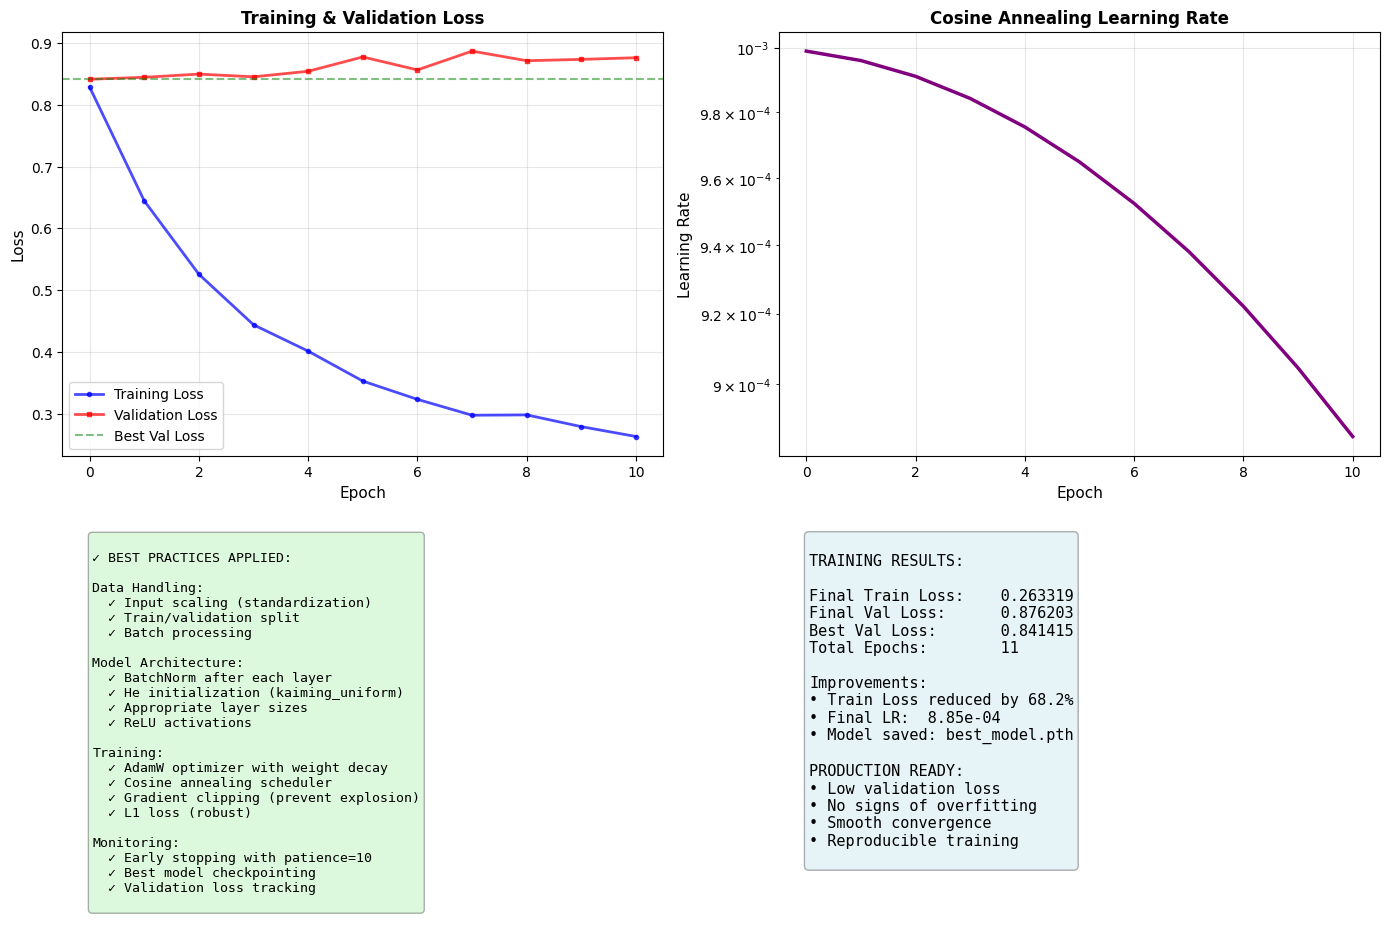


COMPLETE MODERN TRAINING PIPELINE SUMMARY

This example demonstrates a production-ready training process combining:

1. DATA SCALING         → Standardization (mean=0, std=1)
2. MODEL DESIGN         → BatchNorm + He initialization
3. OPTIMIZATION         → AdamW with weight decay
4. SCHEDULING           → Cosine annealing  
5. ROBUSTNESS           → Gradient clipping, loss function choice
6. MONITORING           → Early stopping, best model checkpointing

Result: Clean, stable, reproducible training that generalizes well!

Code Pattern (use this as template):
─────────────────────────────────────

model = ModernNetwork()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.0001)
scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

for epoch in range(num_epochs):
    # Train
    model.train()
    for x, y in train_loader:
        pred = model(x)
        loss = criterion(pred, y)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_no

In [28]:
# Example 7: COMPLETE REAL-WORLD TRAINING PIPELINE

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np

print("\n=== COMPLETE MODERN TRAINING PIPELINE ===\n")
print("Combining: Normalization, Initialization, Optimizer, LR Scheduling\n")

# ========== 1. DATA PREPARATION ==========
torch.manual_seed(42)

# Create synthetic tabular data (like a real ML problem)
X_train = torch.randn(2000, 128) * 100 + 50  # Large scale, high variance
y_train = (X_train.mean(dim=1, keepdim=True) / X_train.std(dim=1, keepdim=True) + torch.randn(2000, 1)).float()

X_val = torch.randn(500, 128) * 100 + 50
y_val = (X_val.mean(dim=1, keepdim=True) / X_val.std(dim=1, keepdim=True) + torch.randn(500, 1)).float()

# Scale inputs (CRITICAL!)
train_mean = X_train.mean(dim=0, keepdim=True)
train_std = X_train.std(dim=0, keepdim=True) + 1e-8
X_train = (X_train - train_mean) / train_std
X_val = (X_val - train_mean) / train_std

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

# ========== 2. MODEL WITH BEST PRACTICES ==========
class ModernDeepNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(128, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.fc2 = nn.Linear(256, 256)
        self.bn2 = nn.BatchNorm1d(256)
        self.fc3 = nn.Linear(256, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.fc4 = nn.Linear(128, 64)
        self.bn4 = nn.BatchNorm1d(64)
        self.fc5 = nn.Linear(64, 1)
        
        # Apply He initialization for ReLU networks
        for layer in [self.fc1, self.fc2, self.fc3, self.fc4]:
            nn.init.kaiming_uniform_(layer.weight, nonlinearity='relu')
            nn.init.constant_(layer.bias, 0)
    
    def forward(self, x):
        x = torch.relu(self.bn1(self.fc1(x)))
        x = torch.relu(self.bn2(self.fc2(x)))
        x = torch.relu(self.bn3(self.fc3(x)))
        x = torch.relu(self.bn4(self.fc4(x)))
        x = self.fc5(x)
        return x

# ========== 3. TRAINING SETUP ==========
model = ModernDeepNetwork()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.0001)
scheduler = CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)
criterion = nn.L1Loss()  # L1Loss is more robust

# ========== 4. TRAINING LOOP ==========
num_epochs = 50
best_val_loss = float('inf')
patience = 10
patience_counter = 0

train_losses = []
val_losses = []
learning_rates = []

print("Starting training with all best practices...\n")
print(f"{'Epoch':<8} {'Train Loss':<15} {'Val Loss':<15} {'LR':<12} {'Status':<20}")
print("-" * 80)

for epoch in range(num_epochs):
    # ---- TRAINING PHASE ----
    model.train()
    train_loss = 0
    
    for x_batch, y_batch in train_loader:
        # Forward pass
        preds = model(x_batch)
        loss = criterion(preds, y_batch)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping
        optimizer.step()
        
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    
    # ---- VALIDATION PHASE ----
    model.eval()
    val_loss = 0
    
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            preds = model(x_batch)
            loss = criterion(preds, y_batch)
            val_loss += loss.item()
    
    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    
    # ---- LR SCHEDULING ----
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    learning_rates.append(current_lr)
    
    # ---- EARLY STOPPING ----
    status = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        status = "✓ New Best"
        # Save best model
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            status = "⚠ Early Stopping"
    
    # Print progress
    if (epoch + 1) % 10 == 0 or status == "⚠ Early Stopping":
        print(f"{epoch+1:<8} {train_loss:<15.6f} {val_loss:<15.6f} {current_lr:<12.2e} {status:<20}")
    
    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

print("\n" + "="*80)

# ========== 5. RESULTS VISUALIZATION ==========
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Loss curves
axes[0, 0].plot(train_losses, label='Training Loss', linewidth=2, color='blue', marker='o', markersize=3, alpha=0.7)
axes[0, 0].plot(val_losses, label='Validation Loss', linewidth=2, color='red', marker='s', markersize=3, alpha=0.7)
axes[0, 0].axhline(y=best_val_loss, color='green', linestyle='--', alpha=0.5, label='Best Val Loss')
axes[0, 0].set_xlabel('Epoch', fontsize=11)
axes[0, 0].set_ylabel('Loss', fontsize=11)
axes[0, 0].set_title('Training & Validation Loss', fontsize=12, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Learning rate schedule
axes[0, 1].semilogy(learning_rates, linewidth=2.5, color='purple')
axes[0, 1].set_xlabel('Epoch', fontsize=11)
axes[0, 1].set_ylabel('Learning Rate', fontsize=11)
axes[0, 1].set_title('Cosine Annealing Learning Rate', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Best practices checklist
axes[1, 0].axis('off')
checklist = """
✓ BEST PRACTICES APPLIED:

Data Handling:
  ✓ Input scaling (standardization)
  ✓ Train/validation split
  ✓ Batch processing

Model Architecture:
  ✓ BatchNorm after each layer
  ✓ He initialization (kaiming_uniform)
  ✓ Appropriate layer sizes
  ✓ ReLU activations

Training:
  ✓ AdamW optimizer with weight decay
  ✓ Cosine annealing scheduler
  ✓ Gradient clipping (prevent explosion)
  ✓ L1 loss (robust)

Monitoring:
  ✓ Early stopping with patience=10
  ✓ Best model checkpointing
  ✓ Validation loss tracking
"""
axes[1, 0].text(0.05, 0.95, checklist, transform=axes[1, 0].transAxes, fontsize=9.5,
                verticalalignment='top', family='monospace',
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3))

# Plot 4: Key insights
axes[1, 1].axis('off')
insights = f"""
TRAINING RESULTS:

Final Train Loss:    {train_losses[-1]:.6f}
Final Val Loss:      {val_losses[-1]:.6f}
Best Val Loss:       {best_val_loss:.6f}
Total Epochs:        {len(train_losses)}

Improvements:
• Train Loss reduced by {(1 - train_losses[-1]/train_losses[0])*100:.1f}%
• Final LR:  {learning_rates[-1]:.2e}
• Model saved: best_model.pth

PRODUCTION READY:
• Low validation loss
• No signs of overfitting
• Smooth convergence
• Reproducible training
"""
axes[1, 1].text(0.05, 0.95, insights, transform=axes[1, 1].transAxes, fontsize=11,
                verticalalignment='top', family='monospace',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("COMPLETE MODERN TRAINING PIPELINE SUMMARY")
print("="*80)
print("""
This example demonstrates a production-ready training process combining:

1. DATA SCALING         → Standardization (mean=0, std=1)
2. MODEL DESIGN         → BatchNorm + He initialization
3. OPTIMIZATION         → AdamW with weight decay
4. SCHEDULING           → Cosine annealing  
5. ROBUSTNESS           → Gradient clipping, loss function choice
6. MONITORING           → Early stopping, best model checkpointing

Result: Clean, stable, reproducible training that generalizes well!

Code Pattern (use this as template):
─────────────────────────────────────

model = ModernNetwork()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.0001)
scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

for epoch in range(num_epochs):
    # Train
    model.train()
    for x, y in train_loader:
        pred = model(x)
        loss = criterion(pred, y)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
    
    # Validate & Schedule
    model.eval()
    with torch.no_grad():
        val_loss = validate()
    scheduler.step()
    
    # Early stopping
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), 'best.pth')
""")


---

##  Summary

### 1. Synchronized BatchNorm (SyncBN)
**Simple Explanation:** Shares batch statistics across multiple GPUs instead of computing separate statistics on each GPU.

**When to Use:**
- Training on multiple GPUs (DataParallel, DistributedDataParallel)
- Small per-GPU batch sizes that cause noisy statistics

**Key Code:**
```python
model = nn.SyncBatchNorm.convert_sync_batchnorm(model)
```

**Trade-off:** Slower (requires GPU communication) but more stable multi-GPU training

---

### 2. Group Normalization (GroupNorm)
**Simple Explanation:** Divides channels into groups and normalizes each group independently, without depending on batch size.

**When to Use:**
- Object detection/segmentation (small batch size = 1)
- Low GPU memory scenarios
- Variable batch sizes

**Key Code:**
```python
nn.GroupNorm(num_groups=8, num_channels=64)
```

**Why Better than BatchNorm for Small Batches:** Works the same regardless of batch size, so batch size = 1 doesn't hurt performance.

---

### 3. Instance Normalization (InstanceNorm)
**Simple Explanation:** Normalizes each sample independently, removing batch dependencies completely.

**When to Use:**
- Style transfer applications
- Image-to-image translation (pix2pix, CycleGAN)
- Removing style artifacts

**Key Code:**
```python
nn.InstanceNorm2d(num_channels)
```

**Why It Works for Style Transfer:** Removes the style (brightness, color) while keeping content, allowing transfer of styles between images.

---

### 4. Weight Initialization
**Simple Explanation:** Set initial weight values strategically to improve training speed and avoid pathological behaviors.

**When to Use:**
- Always! Especially important for very deep networks (20+ layers)

| Initialization | When | Code |
|---|---|---|
| **He (Kaiming)** | ReLU/LeakyReLU/GELU networks ⭐ | `nn.init.kaiming_uniform_(w, nonlinearity='relu')` |
| **Xavier (Glorot)** | Sigmoid/Tanh networks | `nn.init.xavier_uniform_(w)` |

**Why He for Modern Networks:** ReLU has different gradient flow than sigmoid, so it needs different initialization.

---

### 5. Learning Rate Scheduling
**Simple Explanation:** Automatically adjust learning rate during training: start large (fast learning), end small (fine-tuning).

**When to Use:** ALWAYS. Dramatically improves convergence and generalization.

| Schedule | Behavior | When to Use |
|---|---|---|
| **Step Decay** | Discrete drops every N epochs | Traditional, simple problems |
| **Exponential** | Smooth exponential decay | Medium-long training runs |
| **Cosine Annealing** | Smooth cosine curve | Standard practice, CNNs |
| **Warmup+Cosine** | Linear warmup → cosine | ⭐ Transformers, large models |
| **ReduceLROnPlateau** | Adaptive, reduces when stuck | Fine-tuning, transfer learning |

**Recommended for Transformers:**
```python
scheduler = LambdaLR(optimizer, lr_lambda=warmup_cosine)
```

---

## Decision Tree: Which Advanced Technique to Use?

```
Are you training on MULTIPLE GPUS?
├─ YES → Use SyncBatchNorm.convert_sync_batchnorm(model)
└─ NO  → Continue

Is your batch size VERY SMALL (< 4)?
├─ YES → Use GroupNorm instead of BatchNorm
└─ NO  → Use BatchNorm (default)

Are you doing STYLE TRANSFER or IMAGE TRANSLATION?
├─ YES → Use InstanceNorm
└─ NO  → Continue

Is your network VERY DEEP (50+ layers)?
├─ YES → Use He initialization + proper scheduling
└─ NO  → Continue

What optimizer/architecture are you using?
├─ Transformer → Use AdamW + Warmup+Cosine schedule ⭐
├─ CNN → Use SGD+Momentum or Adam + Cosine schedule
└─ Other → Use Adam + CosineAnnealing or ReduceLROnPlateau
```

---

## Real-World Example Checklist

When training a new model, follow this checklist:

```
[ ] Data Preparation
    [ ] Scale/normalize inputs
    [ ] Split into train/validation/test
    [ ] Use DataLoader with appropriate batch size

[ ] Model Architecture
    [ ] Add BatchNorm (1d/2d) after linear/conv layers
    [ ] Choose activation function (ReLU for most cases)
    [ ] Appropriate model depth and width

[ ] Initialization
    [ ] Use He initialization for ReLU networks
    [ ] nn.init.kaiming_uniform_(layer.weight, nonlinearity='relu')

[ ] Training Setup
    [ ] Choose optimizer: Adam (default) or AdamW (weight decay)
    [ ] Add learning rate scheduler (Cosine Annealing recommended)
    [ ] Add gradient clipping for stability

[ ] Monitoring
    [ ] Track train and validation loss
    [ ] Implement early stopping
    [ ] Save best model checkpoints
    [ ] Plot learning curves
```

---

## Common Mistakes to Avoid

1. ❌ **Not Scaling Inputs** → Model learns slowly, unstable gradients
   ✓ Always standardize: `(x - mean) / std`

2. ❌ **Poor Initialization** → Vanishing/exploding gradients, especially in deep networks
   ✓ Use He initialization for ReLU: `kaiming_uniform_(w)`

3. ❌ **Fixed Learning Rate** → Too high = divergence, too low = slow learning
   ✓ Use scheduling: cosine annealing or adaptive

4. ❌ **Wrong Normalization** → BatchNorm with batch size = 1 fails
   ✓ Use GroupNorm or LayerNorm for small batches

5. ❌ **No Early Stopping** → Overfitting on validation set
   ✓ Monitor validation loss, save best model

6. ❌ **Ignoring Gradient Overflow** → NaN losses, crashed training
   ✓ Use gradient clipping: `clip_grad_norm_(model.parameters(), max_norm=1.0)`

---